# **OpenPyTEA** Walkthrough — Part 4: Monte Carlo Uncertainty Analysis

This notebook is **Part 4** of the OpenPyTEA walkthrough series:

1. [Part 1: Defining Equipment](part_1_equipment.ipynb)
2. [Part 2: Creating the Plant](part_2_plant.ipynb)
3. [Part 3: Cost Analysis and Sensitivity](part_3_analysis.ipynb)
4. **Part 4: Monte Carlo Uncertainty Analysis** (this notebook)
5. [Part 5: TEA Using Configuration Files](part_5_configuration_files.ipynb)

## ⚙️ Setup

This part uses the equipment, the fully configured `demo_plant`, the `copy_plant` variant, and the `analysis`/`plotting` imports, which were built step by step in Parts 1 to 3. The cell below recreates them so this notebook can run on its own (make sure **OpenPyTEA** is installed, e.g. `%pip install "openpytea[ipython]"`).

In [1]:
from openpytea import Equipment

# The three pieces of equipment defined in Part 1 (usage examples 1, 2 and 4):
hx = Equipment(
    name="HX-101",
    param=900,                      # m² area
    process_type="Fluids",
    category="Heat Exchangers",
    type="U-tube shell & tube",
    material="316 stainless steel"
)

comp1 = Equipment(
    name='Comp-1',
    process_type='Fluids',
    material='Carbon steel',
    param=1,                        # MW
    category='Compressors, fans, & Blowers',
    type='Compressor, centrifugal',
    cost_func='co2_compressor_manzolini_2011'
)

comp2 = Equipment(
    name="Air Compressor",
    param=50_000,                   # exceeds upper_parallel -> auto-splits into parallel units
    process_type="Fluids",
    category='Compressors, fans, & blowers',
    type='Compressor, centrifugal',
)

In [2]:
from openpytea import Plant

# Consolidated configuration of the demo plant as it stands at the END of Part 2
# (the initial config plus every update_configuration() call made along the way).
config = {
    "plant_name": "Demo Plant",
    "process_type": "Fluids",
    "country": "United States",
    "region": "Gulf Coast",
    "loc_factor": 1.10,                         # overrides the country/region lookup
    "currency": "USD",
    "exchange_rate": 1.0,
    "equipment": [hx, comp1, comp2],
    "interest_rate": 0.08,
    "project_lifetime": 20,
    "plant_utilization": 0.90,
    "tax_rate": 0.25,

    # Capital cost factor overrides
    "fixed_capital_factors": {"osbl": 0.25, "de": 0.35},
    "fixed_capital_components": {"contingency": 15_000_000},

    # Operator labor details
    "operators_hired": 12,
    "operator_hourly_rate": {"rate": 42.0},
    "working_weeks_per_year": 46,
    "working_shifts_per_week": 5,
    "operating_shifts_per_day": 3,

    # Fixed OPEX overrides
    "fixed_opex_factors": {"maintenance": 0.06, "rent_of_land": 0.01, "rnd": 0.0},
    "fixed_opex_components": {"supervision_costs": 100_000},

    # Plant products
    "plant_products": {
        "methanol": {"production": 100_000, "price": 1.95},   # main product
        "hydrogen": {"production": 75_000, "price": 1.25},    # by-product
    },

    # Variable operating expenses
    "variable_opex_inputs": {
        "electricity":   {"consumption": 1.4e6, "price": 0.075},
        "cooling_water": {"consumption": 1.6e6, "price": 0.0007},
        "steam":         {"consumption": 4.0e5, "price": 0.02},
        "natural_gas":   {"consumption": 1.0e5, "price": 0.035},
    },

    # Additional CAPEX and OPEX information
    "working_capital": None,
    "additional_capex_cost": [500_000, 200_000],
    "additional_capex_years": [8, 15],

    # Cash flow profiles
    "capex_ramp": [0.2, 0.5, 0.2, 0.1],
    "production_ramp": [0, 0, 0, 0, 0.4, 0.8],

    # Depreciation: 200% declining balance
    "depreciation": {
        "method": "declining_balance",
        "life": 10,
        "db_factor": 2.0,
        "salvage_fraction": 0.1,
        "service_start_year": 2,
    },
}

demo_plant = Plant(config)
demo_plant.calculate_all()   # runs every calculation from Part 2 (CAPEX, OPEX, cash flow, NPV, LCOP, PBT, ROI, IRR)

In [3]:
from copy import deepcopy
from openpytea.analysis import *
from openpytea.plotting import *

# The "Copied Plant" from Part 3: same plant with a different utility mix
copy_plant = deepcopy(demo_plant)
copy_plant.update_configuration({
    'plant_name': "Copied Plant",
    "variable_opex_inputs": {
        "electricity":   {"consumption": 0.9e6, "price": 0.05},
        "cooling_water": {"consumption": 2.0e6, "price": 0.0007},
        "steam":         {"consumption": 1.3e5, "price": 0.02},
        "natural_gas":   {"consumption": 1.1e6, "price": 0.015}
    },
})
copy_plant.calculate_all()

### 🎲 Monte Carlo Simulation (Probabilistic Sensitivity)

Monte Carlo simulation is a stochastic uncertainty analysis that captures simultaneous variation across multiple uncertain parameters. Each variable is assigned a probability distribution (for example, a truncated normal distribution), and the model is evaluated repeatedly, often thousands or millions of times.

In each iteration, random values are sampled from the specified distributions and used to calculate the selected performance metric. This produces a distribution of outcomes rather than a single deterministic value.

This approach enables evaluation of
- Expected values such as NPV, IRR, LCOP (mean or median),
- The spread of outcomes (variance or confidence intervals),
- The likelihood of exceeding target costs or achieving economic viability.

Monte Carlo analysis therefore provides a probabilistic perspective on economic risk and complements the deterministic insight obtained from sensitivity and tornado analyses.

---

**Defining Uncertain Inputs with Probability Distributions**

Every uncertain input in OpenPyTEA falls into one of two categories:

- **Economic parameters** -- prices, the operator hourly rate, and project-level financial factors (interest rate, fixed capital/OPEX factors, project lifetime, tax rate, plant utilization).
- **Process parameters** -- the physical `consumption` (`variable_opex_inputs`) and `production` (`plant_products`) quantities themselves.

Both are configured the same way: add a `price_uncertainty` sub-dict to an item in `plant_products` or `variable_opex_inputs` to sample its `price` (economic), and/or a `production_uncertainty`/`consumption_uncertainty` sub-dict to sample its `production`/`consumption` (process) -- both can be configured on the same item independently. The operator hourly rate is sampled the same way, via a `rate_uncertainty` sub-dict inside `operator_hourly_rate` (the legacy flat layout -- distribution fields directly alongside `"rate"` -- is still accepted).

By default, every uncertain input is sampled from a **truncated Normal distribution**, using its baseline value (`price`/`rate`/`mean`) as the mean and `std` as the standard deviation. You are not limited to the normal distribution, however: OpenPyTEA lets you pick a different probability distribution model for *any* uncertain input by adding a `dist_id` field to its uncertainty dict.

Under the hood, each `dist_id` maps directly to a distribution object from [`scipy.stats`](https://docs.scipy.org/doc/scipy/reference/stats.html), so sampling reuses `scipy`'s well-tested distribution machinery. Depending on the chosen model, the relevant shape parameters are read from the generic `loc`, `scale`, `shape`, `min`/`minimum`, and `max`/`maximum` fields (`price`, `mean`, and `rate` are all accepted as aliases for `loc`; `std` is an alias for `scale`):

| `dist_id` | Distribution | `scipy.stats` object | Parameters used | Learn more |
| --- | --- | --- | --- | --- |
| 0 or 1 | Deterministic (fixed value, no sampling) | *(none)* | `loc` | — |
| 2 | Lognormal | `lognorm` | `loc`=ln-mean (μ), `scale`=ln-std (σ) | [scipy docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.lognorm.html) |
| 3 (default) | Normal | `norm` | `loc`=mean, `scale`=std | [scipy docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html) |
| 4 | Uniform | `uniform` | `min`, `max` | [scipy docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html) |
| 5 | Triangular | `triang` | `loc`=mode, `min`, `max` | [scipy docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.triang.html) |
| 6 | Bernoulli (scaled) | `bernoulli`-style | `loc`=probability of success *p*, `scale`=success-outcome value (default 1) | [scipy docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bernoulli.html) |
| 7 | Discrete uniform | `randint` | `min`, `max` | [scipy docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.randint.html) |
| 8 | Weibull | `weibull_min` | `loc`=offset, `scale`=λ, `shape`=k | [scipy docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.weibull_min.html) |
| 9 | Gamma | `gamma` | `loc`=offset, `scale`=θ, `shape`=k | [scipy docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gamma.html) |
| 10 | Beta | `beta` | `loc`=α, `shape`=β, `max`=upper bound | [scipy docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.beta.html) |
| 11 | Generalized Extreme Value (GEV) | `genextreme` | `loc`=μ, `scale`=σ, `shape`=ξ | [scipy docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.genextreme.html) |
| 12 | Student's t | `t` | `loc`=median, `scale`=scale, `shape`=ν (degrees of freedom) | [scipy docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html) |

A couple of notes:
- For `dist_id` 2 (Lognormal), 3 (Normal), and 6 (Bernoulli), any `min`/`max` you provide act as **truncation bounds**: samples falling outside them are rejected and re-drawn. For the other distributions, `min`/`max` (where listed above) are used directly as distribution parameters rather than as a truncation filter.
- `dist_id` 0 or 1 disables sampling for that input entirely, which is handy for temporarily "freezing" one variable while exploring the rest.
- The table above covers the distributions currently wired up in OpenPyTEA. The full catalogue of distributions available in `scipy.stats` (in case you want to see what else is out there) is listed here: https://docs.scipy.org/doc/scipy/reference/stats.html#probability-distributions

The example below puts every `dist_id` in the table to use for the **economic** side (prices and the operator rate), one per uncertain input, spread across `plant_products`, `operator_hourly_rate`, and `variable_opex_inputs`. `hydrogen`'s price is the one exception: it omits `dist_id` entirely to show the **default** (Normal) distribution in action. Alongside these, methanol's `production` and electricity's `consumption` -- the **process** side -- each get their own independent uncertainty too, via a `production_uncertainty`/`consumption_uncertainty` sub-dict using the same `std`/`min`/`max`/`dist_id` fields. Process parameters are not restricted to the default Normal distribution either: methanol's `production_uncertainty` below picks Lognormal (`dist_id=2`) instead, while electricity's `consumption_uncertainty` omits `dist_id` to show the default in action:

In [4]:
config = {
    "plant_products": {             
        "methanol": {
            "production": 150_000,
            "production_uncertainty": {  # Process parameter: production quantity, sampled independently
                "dist_id": 2,             # Lognormal distribution -- process parameters aren't limited to Normal either
                "loc": 11.92,             # ln-mean (mu), approx. ln(150,000)
                "scale": 0.07,            # ln-std (sigma)
                "min": 100_000,
                "max": 200_000,
            },
            "price": 1.75,           # Economic parameter: baseline price
            "price_uncertainty": {   # Used as the mode for the Triangular distribution
                "dist_id": 5,            # Triangular distribution (see dist_id table above)
                "min": 1.25,             # Minimum plausible price
                "max": 2.25              # Maximum plausible price
            }
        },
        "hydrogen": {
            "production": 50_000,
            "price": 1.25,
            "price_uncertainty": {   # dist_id omitted -> uses the DEFAULT distribution (Normal, dist_id=3)
                "std": 0.1,              # Standard deviation (uncertainty)
                "min": 0.75,             # Minimum plausible price
                "max": 1.75              # Maximum plausible price
            }
        }
    },
    "operator_hourly_rate": {
        "rate": 38.11,              # This is in $/hour (baseline value, used outside Monte Carlo)
        "rate_uncertainty": {       # Uncertainty sub-dict, uniform with price/consumption/production_uncertainty
            "dist_id": 2,           # Lognormal distribution -- keeps the sampled rate positive
            "loc": 3.64,            # ln-mean (mu), approx. ln(38.11)
            "scale": 0.15,          # ln-std (sigma)
            "min": 20.0,            # Minimum plausible rate (truncation bound)
            "max": 60.0             # Maximum plausible rate (truncation bound)
        }
    },
    "variable_opex_inputs": {
        "electricity": {
            "consumption": 1.4e6,   # Daily consumption
            "consumption_uncertainty": {  # Process parameter: consumption quantity, sampled independently
                "std": 1.4e5,              # 10% of the baseline consumption
                "min": 1.0e6,
                "max": 1.8e6,
            },
            "price": 0.1,            # Economic parameter: baseline unit price
            "price_uncertainty": {
                "dist_id": 8,            # Weibull distribution
                "loc": 0.02,             # Offset
                "scale": 0.09,           # Lambda (scale parameter)
                "shape": 2.0             # k (shape parameter)
            }
        },
        "cooling_water": {
            "consumption": 1.6e6,   # Daily consumption
            "price": 0.0008,        # Baseline unit price
            "price_uncertainty": {
                "dist_id": 9,            # Gamma distribution
                "loc": 0.0,              # Offset
                "scale": 0.0002,         # Theta (scale parameter)
                "shape": 4                # k (shape parameter)
            }
        },
        "steam": {
            "consumption": 4.0e5,   # Daily consumption
            "price": 0.04,          # Baseline unit price (unused by dist_id=4)
            "price_uncertainty": {
                "dist_id": 4,            # Uniform distribution
                "min": 0.00,             # Lower bound
                "max": 0.08              # Upper bound
            }
        },
        "natural_gas": {
            "consumption": 1.0e5,   # Daily consumption
            "price": 0.05,          # Baseline unit price
            "price_uncertainty": {
                "dist_id": 11,           # Generalized Extreme Value (GEV) distribution -- models price-spike risk
                "loc": 0.045,            # mu
                "scale": 0.015,          # sigma
                "shape": 0.15            # xi (tail heaviness)
            }
        }
        # Add more variable OPEX items as needed
    }
}

demo_plant.update_configuration(config)

**Defining Project-Level Financial Uncertainties**

Uncertainties for project-wide financial parameters are controlled through the `project_uncertainties` configuration key. Each entry is a sub-dict with optional `std`, `min`, and `max` fields, and can take a `dist_id` too, exactly like the product and OPEX items above:

In [5]:
config = {
    "project_uncertainties": {
        "fixed_capital_factor":  {"dist_id": 3,  "std": 0.3, "min": 0.25, "max": 1.75},   # Normal (same as default; shown explicitly)
        "fixed_opex_factor":     {"dist_id": 12, "loc": 1.0, "scale": 0.08, "shape": 8},  # Student's t -- fat-tailed multiplier
        "project_lifetime":      {"dist_id": 7,  "min": 25, "max": 35},                   # Discrete uniform -- whole years only
        "interest_rate":         {"dist_id": 10, "loc": 3, "shape": 7, "max": 0.3},       # Beta -- naturally bounded in [0, max]
        "plant_utilization":     {"dist_id": 1},                                          # Deterministic -- frozen at baseline (dist_id=0 is equivalent)
        "tax_rate":              {"dist_id": 6,  "loc": 0.5, "scale": 0.25},              # Bernoulli -- 50% chance of a tax holiday (0%), else 25%
    }
}

demo_plant.update_configuration(config)

The first four parameters are **active by default**; `plant_utilization` and `tax_rate` require an explicit `std > 0` (or a `dist_id`) to be sampled. 

When `min`/`max` are omitted they are auto-derived as +/- 2 x std around the plant baseline (clamped to valid ranges). Set any `std=0` to disable sampling for that parameter.


| **`project_uncertainties` key**   | **Description**                                           | **Default std** |
| --------------------------------- | --------------------------------------------------------- | --------------- |
| `fixed_capital_factor`            | Multiplicative factor on total installed CAPEX.           | 0.3 (30%)       |
| `fixed_opex_factor`               | Multiplicative factor on annual fixed OPEX.               | 0.3 (30%)       |
| `project_lifetime`                | Economic project life (years).                            | 5 years         |
| `interest_rate`                   | Discount / financing rate.                                | 0.03 (3%)       |
| `plant_utilization`               | Yearly fraction of operational time.                      | 0 (opt-in)      |
| `tax_rate`                        | Corporate tax rate.                                       | 0 (opt-in)      |

---

**Running Monte Carlo**

The following line from the `analysis` module runs the Monte Carlo analysis with 1,000,000 samples:

In [6]:
mc_results = monte_carlo(
    demo_plant,
    num_samples= 100_000, # This is the number of Monte Carlo samples to run. Increase for more accurate results, decrease for faster runtime.
    batch_size= 10000, # This is the number of samples to run in each batch. Adjust based on your system's memory capacity (e.g., 1000, 10_000, 100_000)
)

Monte Carlo:   0%|          | 0/10 [00:00<?, ?it/s]

After running `monte_carlo()`, the `Plant` object stores the simulation results for all economic metrics (e.g., LCOP, PBT, etc.). These results can then be visualized using the following function:

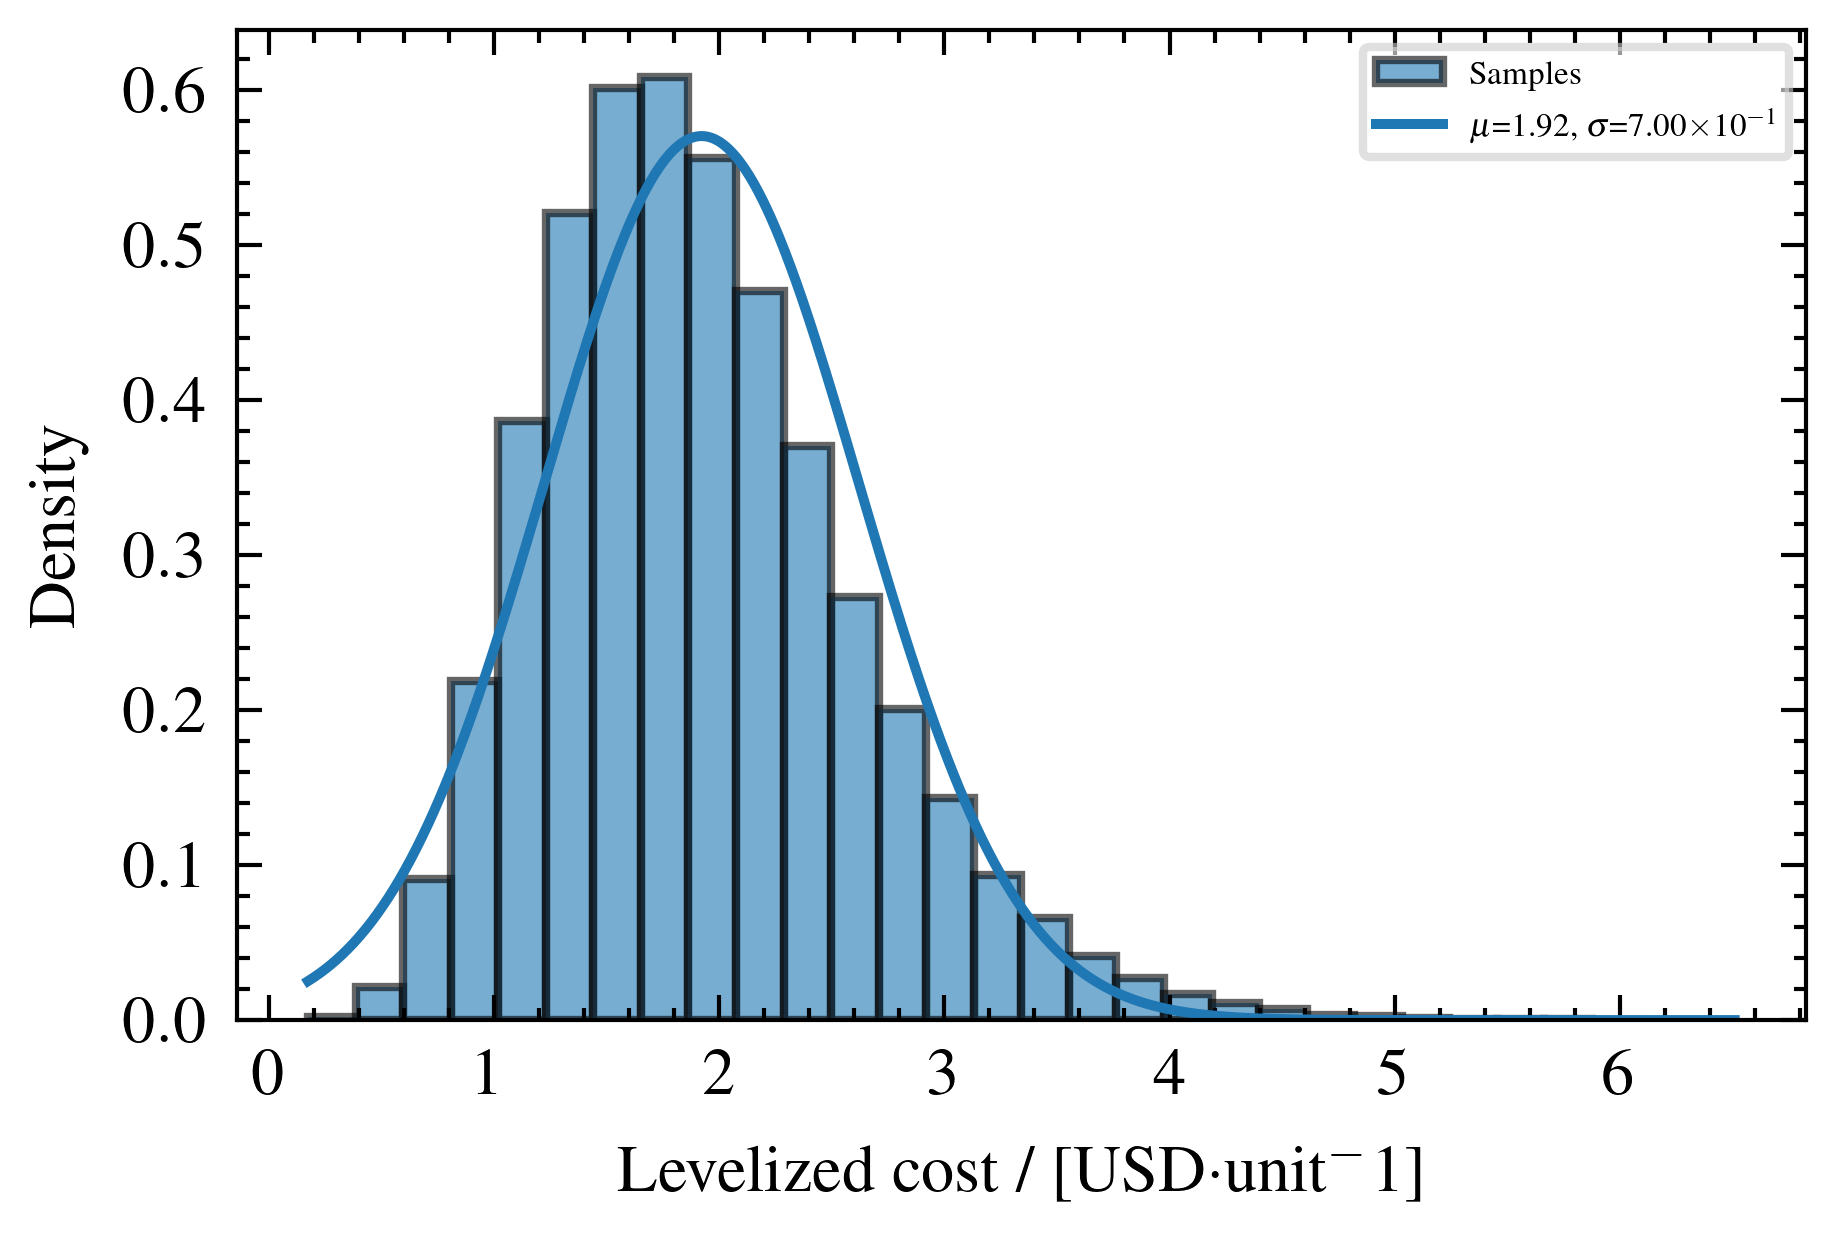

In [7]:
fig, ax = plot_monte_carlo(demo_plant, metric="LCOP", bins=30) #  This will plot the Monte Carlo distribution for LCOP.
# You can change the metric to "NPV", "PBT", "ROI", or "IRR" as needed.
# Adjust the number of bins in the histogram with the bins parameter.

We can also plot the Monte Carlo results for the NPV evaluation:

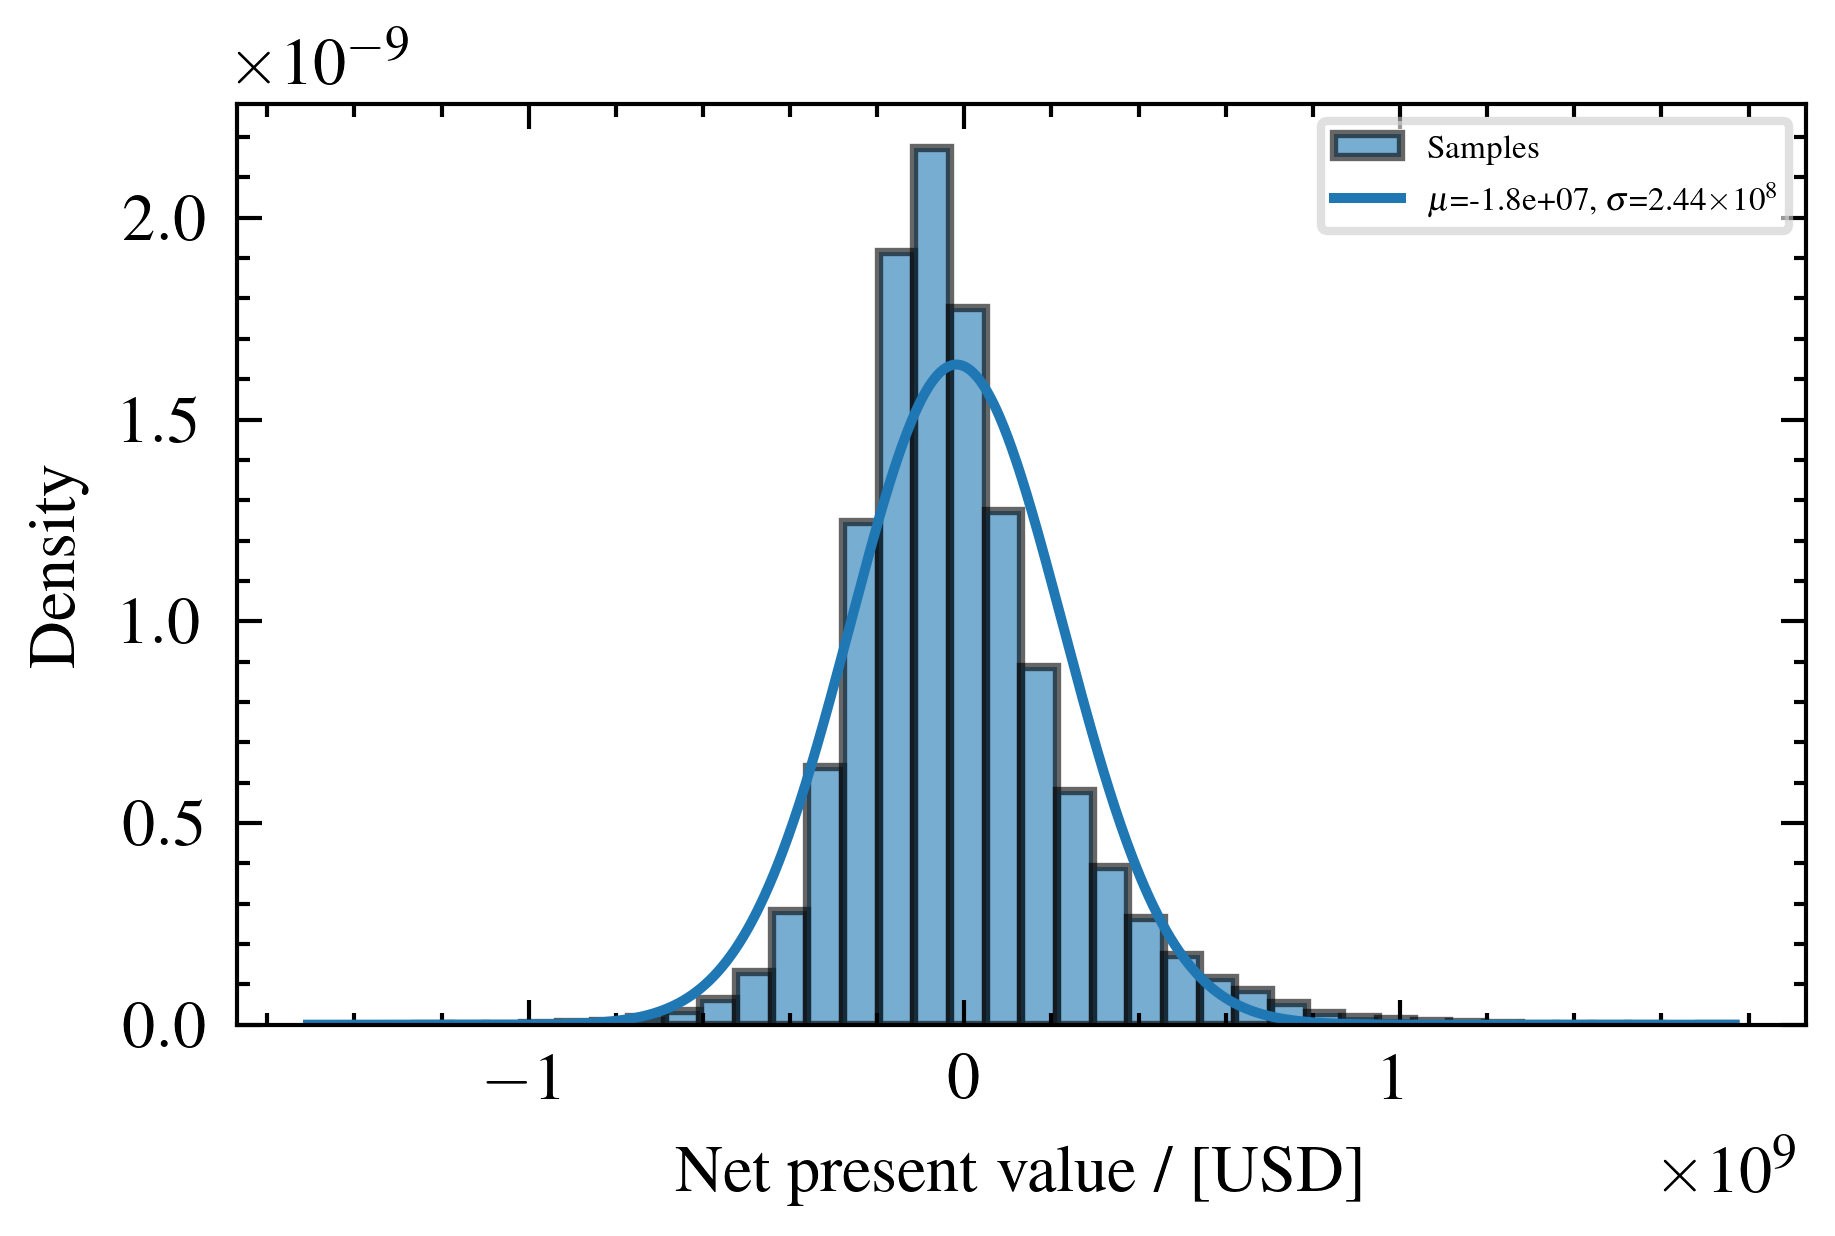

In [8]:
fig, ax = plot_monte_carlo(mc_results, metric="NPV", bins=40)

The distributions of the sampled input variables can also be visualized to verify that the specified uncertainties are correctly represented in the simulation. This is useful for confirming the spread and bounds of the input parameters before interpreting the resulting economic metrics.

`plot_monte_carlo_inputs` splits inputs into the same two categories introduced earlier -- **process** parameters (consumption/production quantities) and **economic** parameters (prices, rates, and the other `project_uncertainties` factors) -- and returns one figure per category. The default `category="both"` builds and returns both:

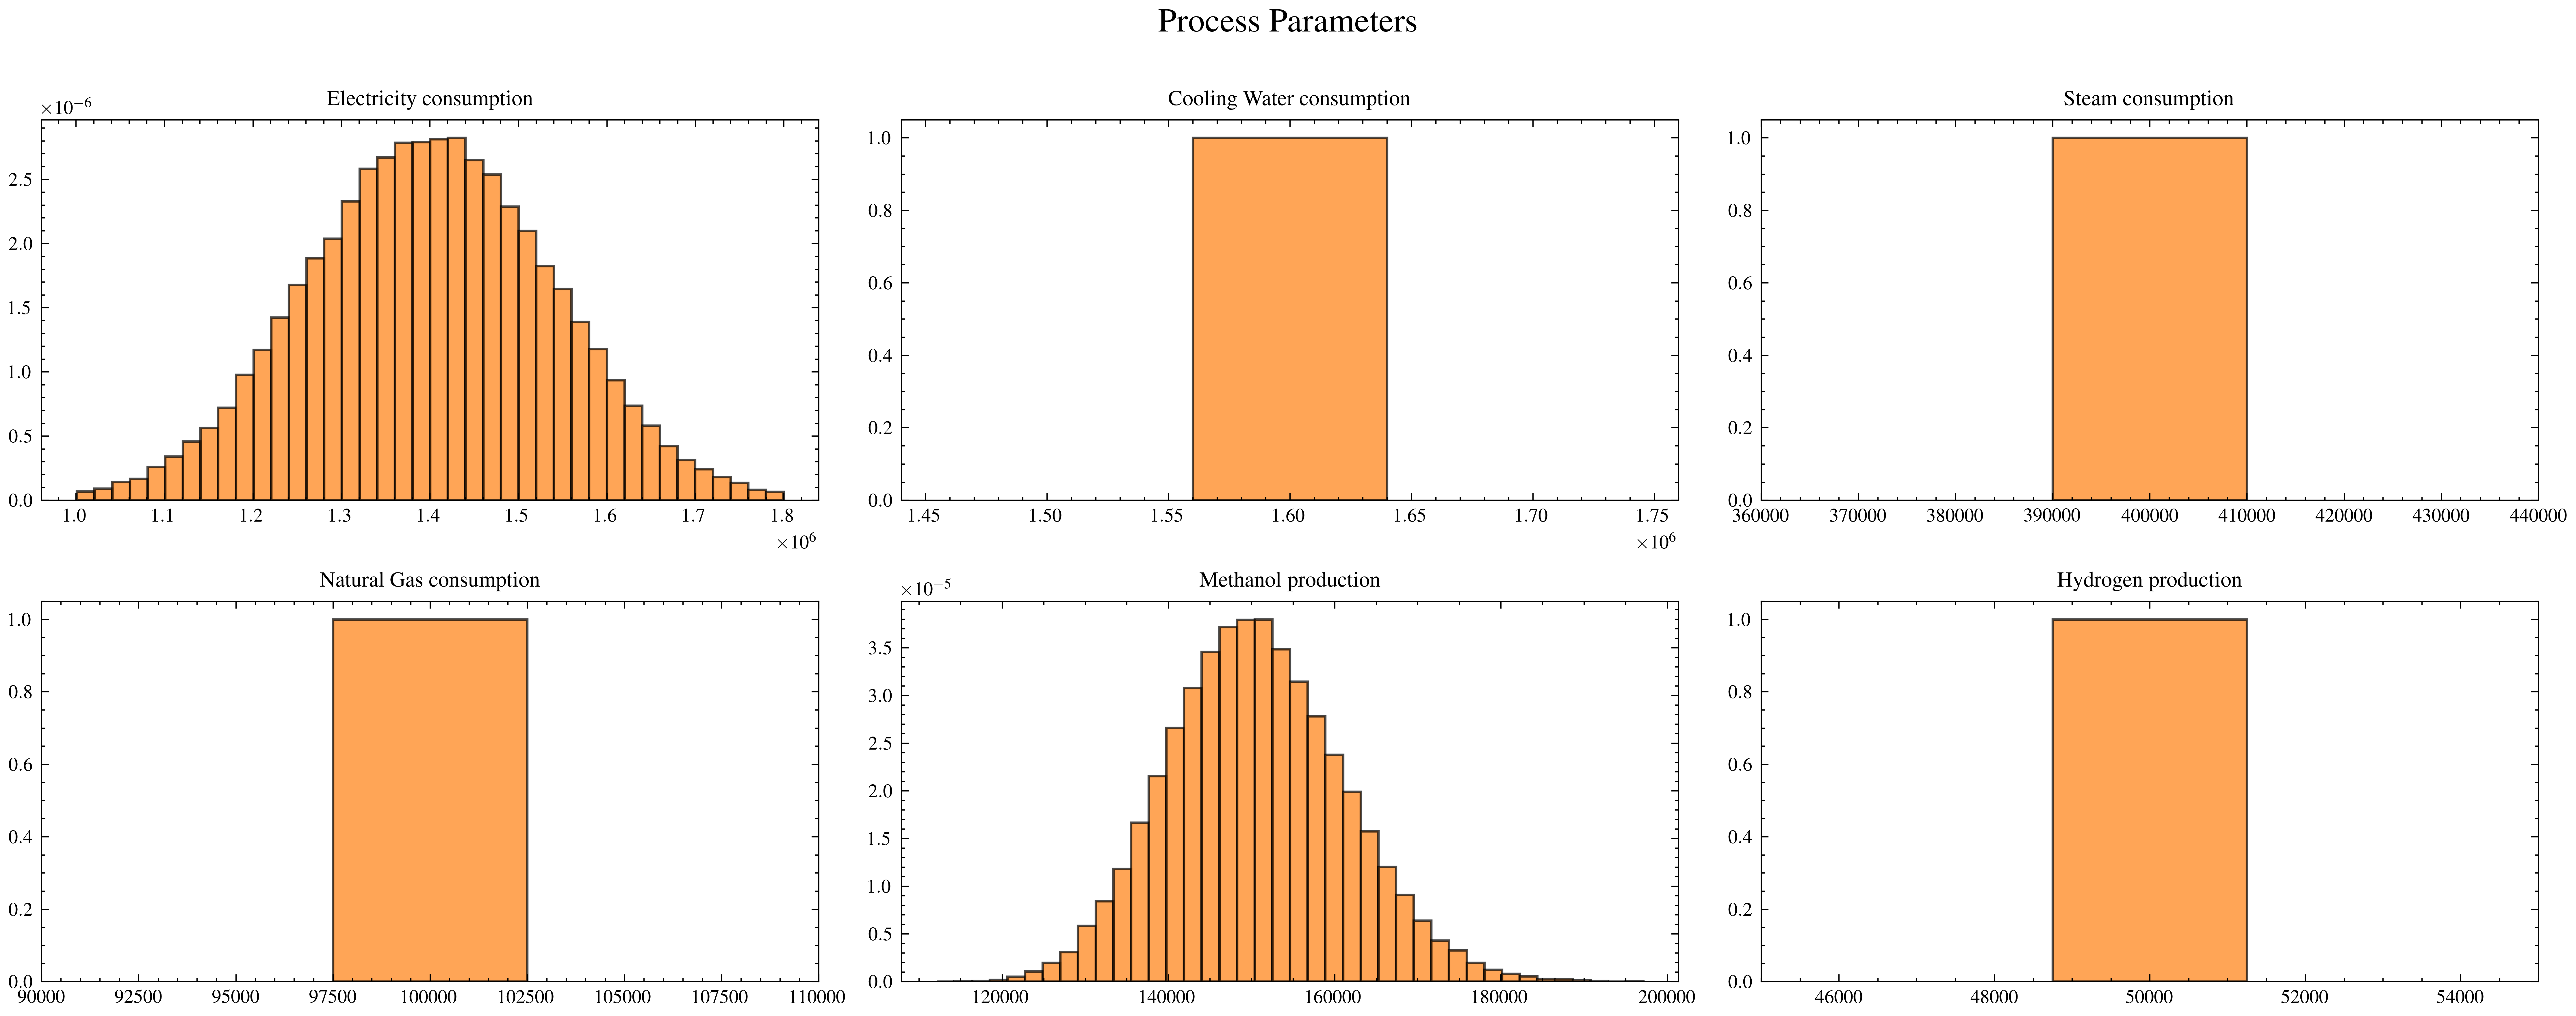

In [9]:
fig_process, axes_process, fig_economic, axes_economic = plot_monte_carlo_inputs(mc_results, bins=40)
# category="both" (the default) returns (fig_process, axes_process, fig_economic, axes_economic).
# Adjust the number of bins with the bins parameter.

Notice that **every** `variable_opex_inputs` item's consumption and **every** product's production shows up in the process figure -- including `hydrogen`'s production and `cooling_water`/`steam`/`natural_gas`'s consumption, none of which were given their own `*_uncertainty` sub-dict. Each renders as a single bar at its fixed baseline value instead of being left out, so you can see the complete process picture -- what varies and what is held fixed -- at a glance.

Pass `category="process"` or `category="economic"` to get just one figure back instead, as a plain `(fig, axes)` pair -- handy when you only want to double-check one side, e.g. the economic assumptions:

In [10]:
fig, axes = plot_monte_carlo_inputs(mc_results, category="economic", bins=40)

If you have multiple plants, you can plot their probability distributions in a single figure to enable direct comparison of economic performance under uncertainty. This allows you to assess differences in expected values, variability, and risk profiles across different technologies or scenarios. Let's now create the copy of the demo plant with different variable OPEX uncertainties to demonstrate this.

In [11]:
config = {
    "variable_opex_inputs": {
        "electricity":   {"price": 0.05, "price_uncertainty": {"dist_id": 3, "std": 0.025, "min": 0.01, "max": 0.1}},        # Normal (demo_plant uses Weibull for electricity)
        "cooling_water": {"price": 0.0007, "price_uncertainty": {"dist_id": 5, "min": 0.0001, "max": 0.0014}},                # Triangular (demo_plant uses Gamma)
        "steam":         {"price": 0.02, "price_uncertainty": {"dist_id": 2, "loc": -3.91, "scale": 0.3, "min": 0.00, "max": 0.08}},  # Lognormal (demo_plant uses Uniform)
        "natural_gas":   {"price": 0.015, "price_uncertainty": {"dist_id": 9, "loc": 0.0, "scale": 0.005, "shape": 3}}        # Gamma (demo_plant uses GEV)
    },
    "project_uncertainties": {
        "plant_utilization": {"dist_id": 4, "min": 0.85, "max": 0.95},         # Uniform (demo_plant freezes this with dist_id=1)
        "tax_rate":          {"dist_id": 3, "loc": 0.25, "std": 0.05, "min": 0.15, "max": 0.35},  # Normal (demo_plant uses Bernoulli)
    }
}

copy_plant.update_configuration(config)

In [12]:
mc_copy = monte_carlo(
    copy_plant,
    num_samples= 100_000,
    batch_size= 10000,
)

Monte Carlo:   0%|          | 0/10 [00:00<?, ?it/s]

C:\Users\pbtamarona\OneDrive - Delft University of Technology\Documents\github-pbtamarona\OpenPyTEA\src\openpytea\plant.py:1238: UserWarning: Depreciation life exceeds the usable horizon (project lifetime minus service start year), so part of the depreciable basis is not written off within the project. This is legitimate for a statutory life longer than the project, but shorten the depreciation life or extend the project lifetime if a full write-off is intended.
  build_depreciation_array(


You can generate the comparison plot as follows:

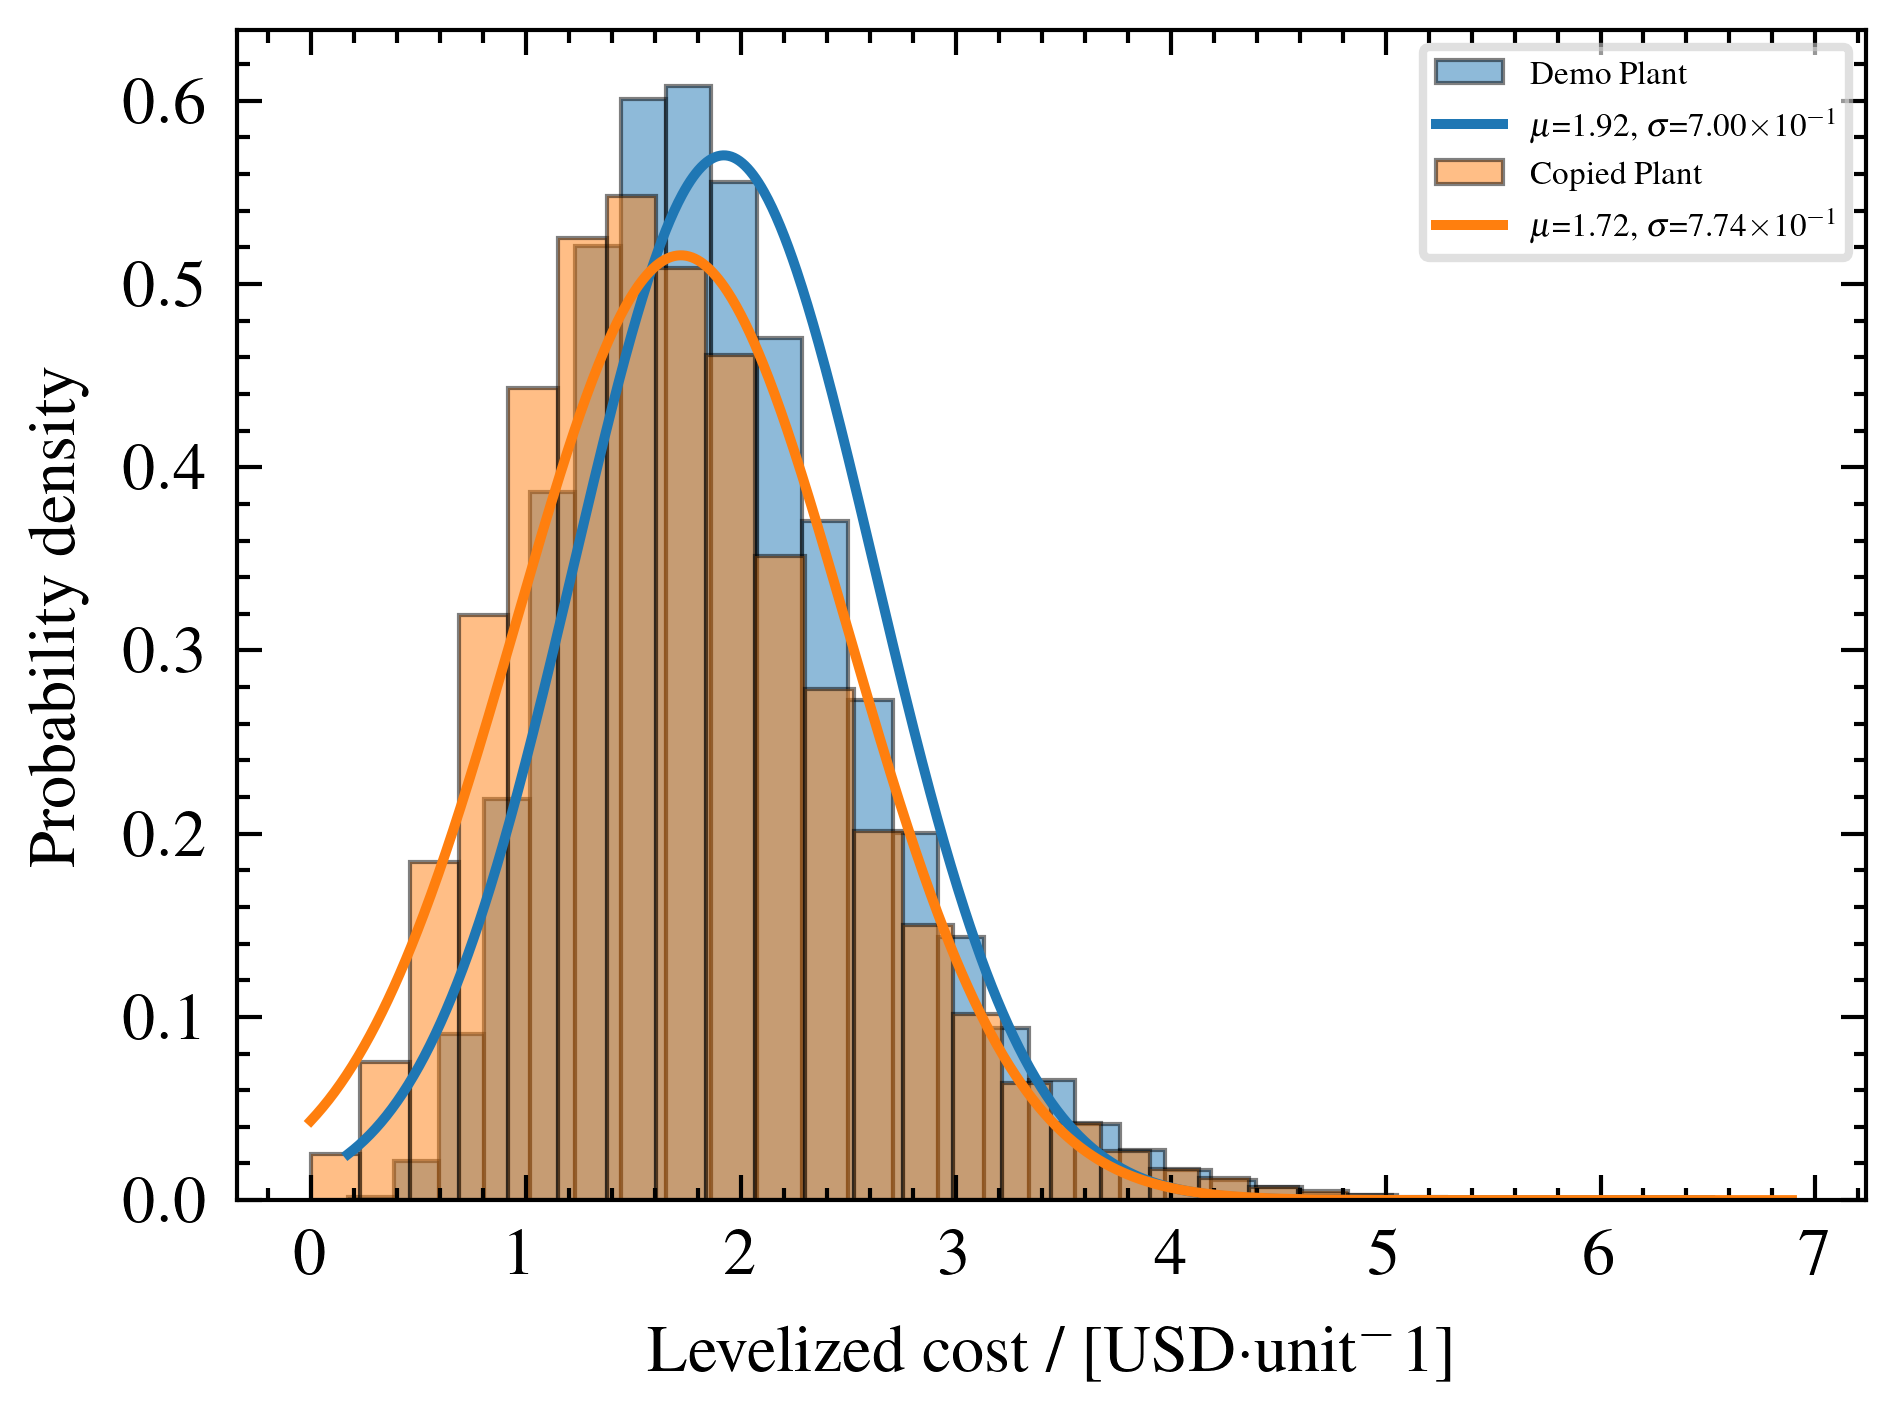

In [13]:
fig, ax = plot_multiple_monte_carlo(
    data_list=[demo_plant, copy_plant],
    metric="LCOP", bins=30
    )

---

**Dependencies Between Process and Economic Parameters**

So far, every parameter that carried uncertainty was sampled independently. OpenPyTEA also lets you tie a consumption/production quantity -- or one of the plant's economic scalars (the six `project_uncertainties` entries plus `operator_hourly_rate`) -- to one or more *other* sampled quantities through a **dependency**, in either direction: process parameters can drive each other (e.g. cooling water consumption scaling with methanol production), and process and economic parameters can drive each other too (e.g. a higher production capacity requiring more fixed capital). Together, every such dependency forms a small **DAG** (directed acyclic graph): nodes are these parameters, edges are the references between them, and OpenPyTEA resolves the whole graph in topological order every run.

Here's the graph this section builds up, as a preview (arrows point from a parent/driver to the dependent it feeds -- process nodes and the one economic node are mixed in freely):

```
methanol production (root)
  |
  +--> hydrogen production
  |
  +--> cooling_water consumption --> steam consumption
  |
  +--> fixed_capital_factor  [economic]
  |
  +--> natural_gas consumption <-- hydrogen production
```

A dependent's value follows a simple linear equation:

$$
\text{dependent} = \sum_i w_i \cdot \text{parent}_i \;+\; b
$$

| Term | Meaning | Defined via |
| --- | --- | --- |
| $\text{parent}_i$ | The $i$-th driver quantity this dependent is tied to -- always its own *resolved* value, so a chain of dependencies resolves in order down the graph. | A key in the `"depends_on"` dict: `"production:<product>"`, `"consumption:<item>"`, or `"project:<param>"`. |
| $w_i$ | The linear weight applied to that parent. | The value paired with that key in `"depends_on"`, e.g. `{"production:methanol": 9.3}` sets $w = 9.3$ for that parent. |
| $b$ | A constant added after the weighted sum. | The `"offset"` field (default `0.0`). |
| $\text{dependent}$ | The resulting value for this node itself. | Whichever block owns it: `"consumption_dependency"` (on a `variable_opex_inputs` item), `"production_dependency"` (on a `plant_products` item), or `"dependency"` (on a `project_uncertainties` entry or `operator_hourly_rate`). |

Chains are resolved automatically, so a dependent's driver can itself be another dependent, and any of these parameters -- process or economic -- can be a driver or a dependent interchangeably. Below, cooling water consumption is tied to methanol production, steam consumption is chained onto cooling water consumption, hydrogen's byproduct production is tied directly to methanol's (main product) production -- a common pattern where a co-product's yield scales with the main product rather than varying on its own -- natural gas consumption depends on **both** methanol and hydrogen production at once (since `depends_on` can map several parents to their own weight, combined linearly), and `fixed_capital_factor` -- an **economic** parameter -- is tied to production capacity as well, since a plant sized for more methanol needs proportionally more fixed capital. Choosing `weight = baseline / driver_baseline` keeps each dependent's mean aligned with its original baseline value:

In [14]:
config = {
    "plant_products": {
        "hydrogen": {
            "production_dependency": {
                "depends_on": {"production:methanol": 50_000 / 150_000},  # Ties hydrogen's byproduct production to methanol production
            }
        },
    },
    "variable_opex_inputs": {
        "cooling_water": {
            "consumption_dependency": {
                "depends_on": {"production:methanol": 1.6e6 / 150_000},  # kg of cooling water per kg of methanol produced (matches the original baseline)
            }
        },
        "steam": {
            "consumption_dependency": {
                "depends_on": {"consumption:cooling_water": 4.0e5 / 1.6e6},  # Chained: steam follows cooling water, which follows production
            }
        },
        "natural_gas": {
            "consumption_dependency": {
                "depends_on": {  # Multiple parents, combined linearly -- fuel gas shared across both product streams
                    "production:methanol": 0.4667,  # ~70% of the baseline consumption
                    "production:hydrogen": 0.6,     # ~30% of the baseline consumption
                },
            }
        },
    },
    "project_uncertainties": {
        "fixed_capital_factor": {  # An *economic* parameter, tied to production capacity
            "dependency": {
                "depends_on": {"production:methanol": 2.0e-6},  # Scales up with production capacity
                "offset": 0.7,                                  # 0.7 + 2.0e-6 * 150,000 = 1.0 at baseline, matching the original mean
                # Since it's an economic parameter, it'll show up in the **economic** category, not the process one, when we plot the inputs below.
            },
        },
    },
}

demo_plant.update_configuration(config)

> **Setting a dependency supersedes any uncertainty the parameter already had.** `update_configuration` normally *merges* nested dicts, but a parameter's own distribution spec (`dist_id`/`std`/`min`/`max`) stops describing it once it becomes a dependent -- its value now comes from the dependency instead. So those fields are dropped rather than merged, leaving only what the call itself specifies. That matters here: `fixed_capital_factor` was configured earlier in this notebook with its own `std` and `min`/`max`, and merging those in would leave it carrying a spec that no longer applies to it.

> **Circular dependencies are rejected, not silently resolved.** If two or more items end up depending on each other -- directly, or through a longer chain -- OpenPyTEA can't tell which one to compute first, so it raises a clear `ValueError` immediately instead of hanging or guessing. The cell below creates a loop on a throwaway copy of `demo_plant` by also making methanol's production depend on steam's consumption, closing the `methanol -> cooling_water -> steam -> methanol` loop:

In [15]:
invalid_plant = deepcopy(demo_plant)
invalid_plant.update_configuration({
    "plant_products": {
        "methanol": {
            "production_dependency": {
                "depends_on": {"consumption:steam": 1.0},  # Closes the loop back onto methanol
            },
        },
    },
})

try:
    monte_carlo(invalid_plant, num_samples=1_000, batch_size=1_000)
except ValueError as e:
    print(f"ValueError: {e}")

ValueError: Could not resolve consumption/production/project dependency(ies) for: consumption:cooling_water, consumption:steam, consumption:natural_gas, production:methanol, production:hydrogen, project:fixed_capital_factor. Each 'depends_on' entry must reference a known variable_opex_inputs/plant_products item or one of ['fixed_capital_factor', 'fixed_opex_factor', 'interest_rate', 'operator_hourly_rate', 'plant_utilization', 'project_lifetime', 'tax_rate'] (directly or transitively), and the dependency DAG must not contain a cycle.


**A dependent's own noise**

Unlike an independent item, a dependent can *also* define its matching `*_uncertainty` block. For a dependent, this becomes **additive noise** on top of the DAG-implied mean rather than parameterizing an absolute value, so `loc`/`mean` default to `0` (not the item's baseline). Since this is no longer the item's own standard deviation, it must be written as `"noise"`, not `"std"`/`"scale"`: those still work for the independent items elsewhere in this notebook (where they really do mean the item's own std), but for a dependent they raise a `ValueError` instead of being silently reinterpreted. Let's give both dependents above some noise of their own: cooling water's consumption, and `fixed_capital_factor` -- showing that a process and an economic dependent take it the same way:

In [16]:
config = {
    "variable_opex_inputs": {
        "cooling_water": {
            "consumption_uncertainty": {
                "dist_id": 3,    # Normal -- the default; any dist_id from the table above works here too
                "noise": 5.0e4,  # Noise around the DAG-implied mean, not the item's own std
            },
        },
    },
    "project_uncertainties": {
        "fixed_capital_factor": {
            "noise": 0.1,  # Same idea for an economic dependent
        },
    },
}

demo_plant.update_configuration(config)

A dependent's noise is drawn through the same `dist_id` machinery as every other uncertain input, so it isn't restricted to the Normal default -- `dist_id` picks any family from the table above.

**Running it**

With the dependencies and their own noise in place, running Monte Carlo on `demo_plant` resolves the whole DAG: methanol production and hydrogen's byproduct production are sampled, cooling water and steam consumption are derived from them (steam tracking cooling water's *actual*, noisy value -- noise propagates downstream through the graph), natural gas consumption is derived from both methanol and hydrogen production at once, and `fixed_capital_factor` -- an economic parameter -- is derived from methanol production too:

In [17]:
mc_dependency = monte_carlo(
    demo_plant,
    num_samples=100_000,
    batch_size=10_000,
)

Monte Carlo:   0%|          | 0/10 [00:00<?, ?it/s]

Plotting just the process-parameter inputs (via `category="process"`) confirms every quantity was sampled -- the independently-sampled ones (`Methanol production`, `Electricity consumption`), the dependent that carries its own noise (`Cooling Water consumption`), and the noise-free dependents (`Steam consumption`, `Natural Gas consumption`, `Hydrogen production`):

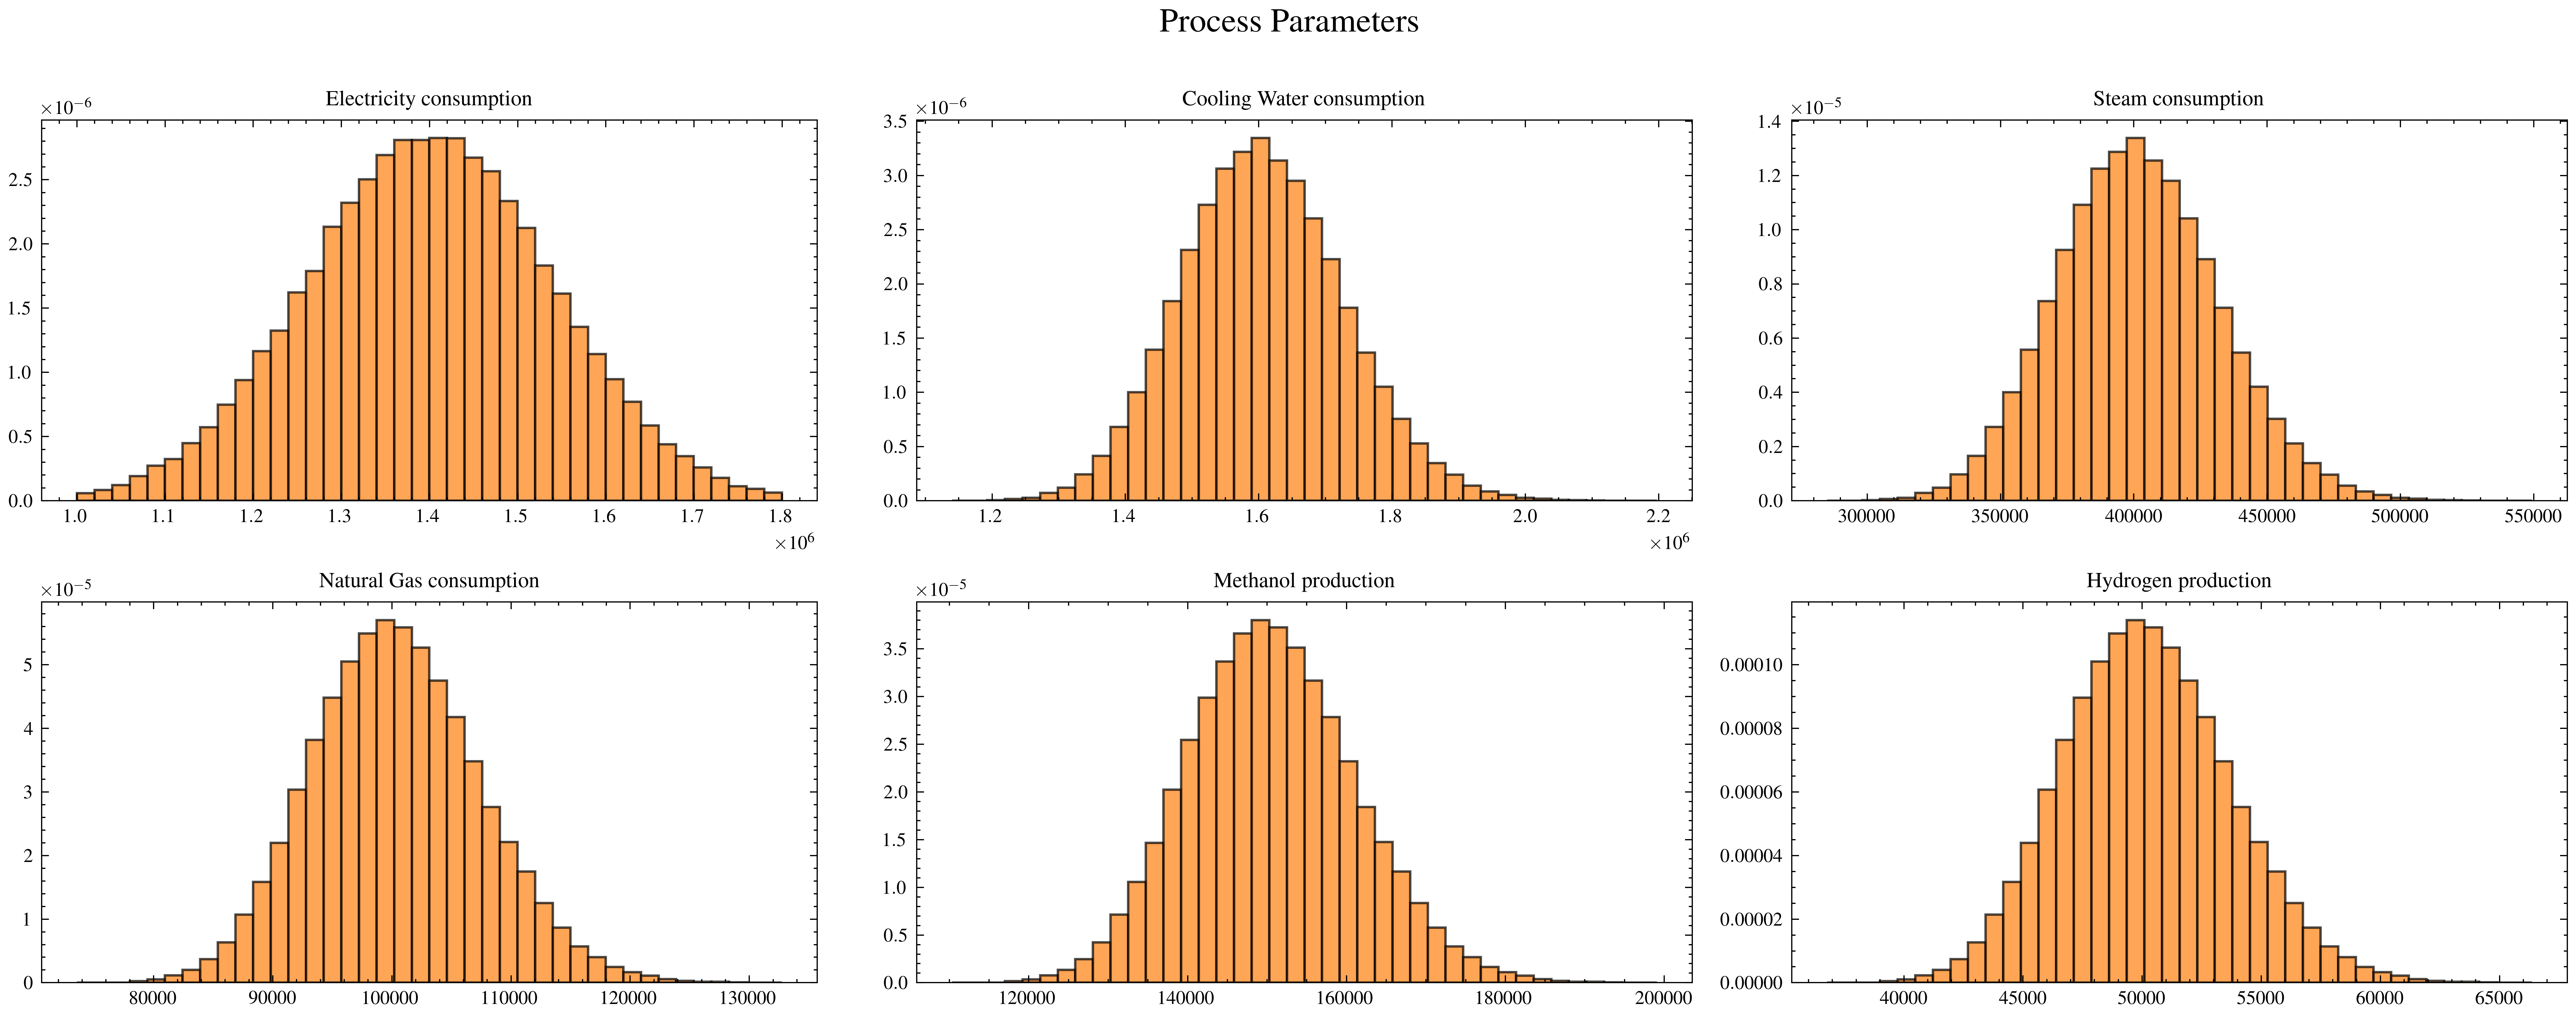

In [18]:
fig, axes = plot_monte_carlo_inputs(mc_dependency, category="process", bins=40)

The economic parameters -- via `category="economic"` -- include `fixed_capital_factor`, now shaped by its dependency instead of the plain Normal it had earlier in the notebook:

In [19]:
fig, axes = plot_monte_carlo_inputs(mc_dependency, category="economic", bins=40)

A scatter plot confirms the shape of each relationship: cooling water tracks methanol production with visible scatter from its own noise, while steam, hydrogen, and natural gas -- none of which carry noise of their own -- land exactly on their drivers, natural gas on the weighted combination of *both* its parents:

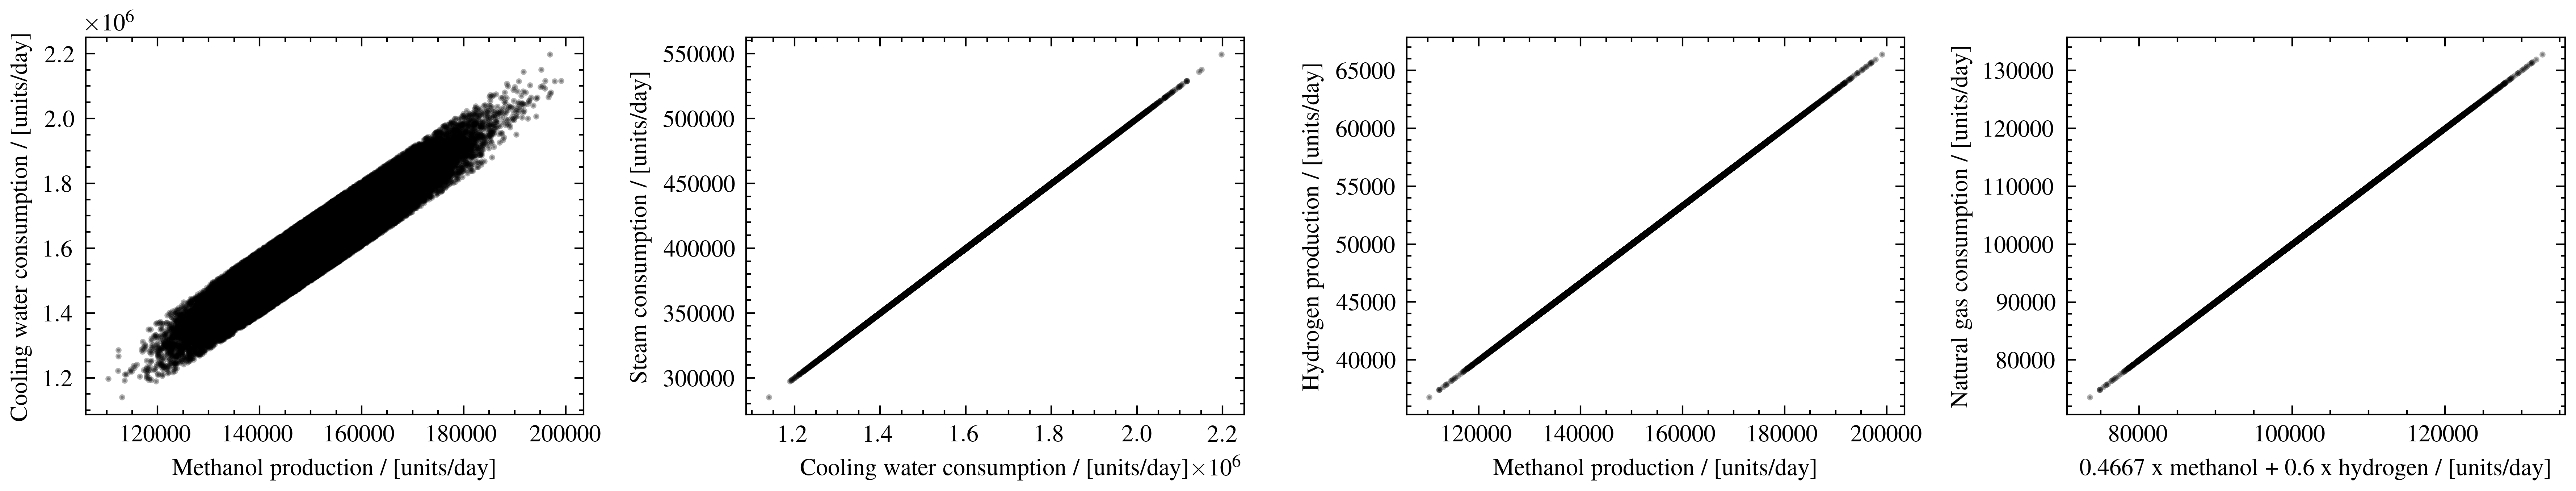

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(12, 2.4))

axes[0].scatter(mc_dependency["inputs"]["Methanol production"],
                mc_dependency["inputs"]["Cooling Water consumption"],
                s=1, alpha=0.3)
axes[0].set_xlabel("Methanol production / [units/day]")
axes[0].set_ylabel("Cooling water consumption / [units/day]")

axes[1].scatter(mc_dependency["inputs"]["Cooling Water consumption"],
                mc_dependency["inputs"]["Steam consumption"],
                s=1, alpha=0.3)
axes[1].set_xlabel("Cooling water consumption / [units/day]")
axes[1].set_ylabel("Steam consumption / [units/day]")

axes[2].scatter(mc_dependency["inputs"]["Methanol production"],
                mc_dependency["inputs"]["Hydrogen production"],
                s=1, alpha=0.3)
axes[2].set_xlabel("Methanol production / [units/day]")
axes[2].set_ylabel("Hydrogen production / [units/day]")

# Natural gas has two parents and no noise of its own, so it lands exactly on
# the weighted combination of both
ng_mean = (0.4667 * mc_dependency["inputs"]["Methanol production"]
           + 0.6 * mc_dependency["inputs"]["Hydrogen production"])

axes[3].scatter(ng_mean, mc_dependency["inputs"]["Natural Gas consumption"], s=1, alpha=0.3)
axes[3].set_xlabel("0.4667 x methanol + 0.6 x hydrogen / [units/day]")
axes[3].set_ylabel("Natural gas consumption / [units/day]")

fig.tight_layout()
plt.show()

The same check applies to `fixed_capital_factor`: it tracks methanol production with visible scatter from its own noise, just like cooling water does -- a process and an economic dependent behave identically here:

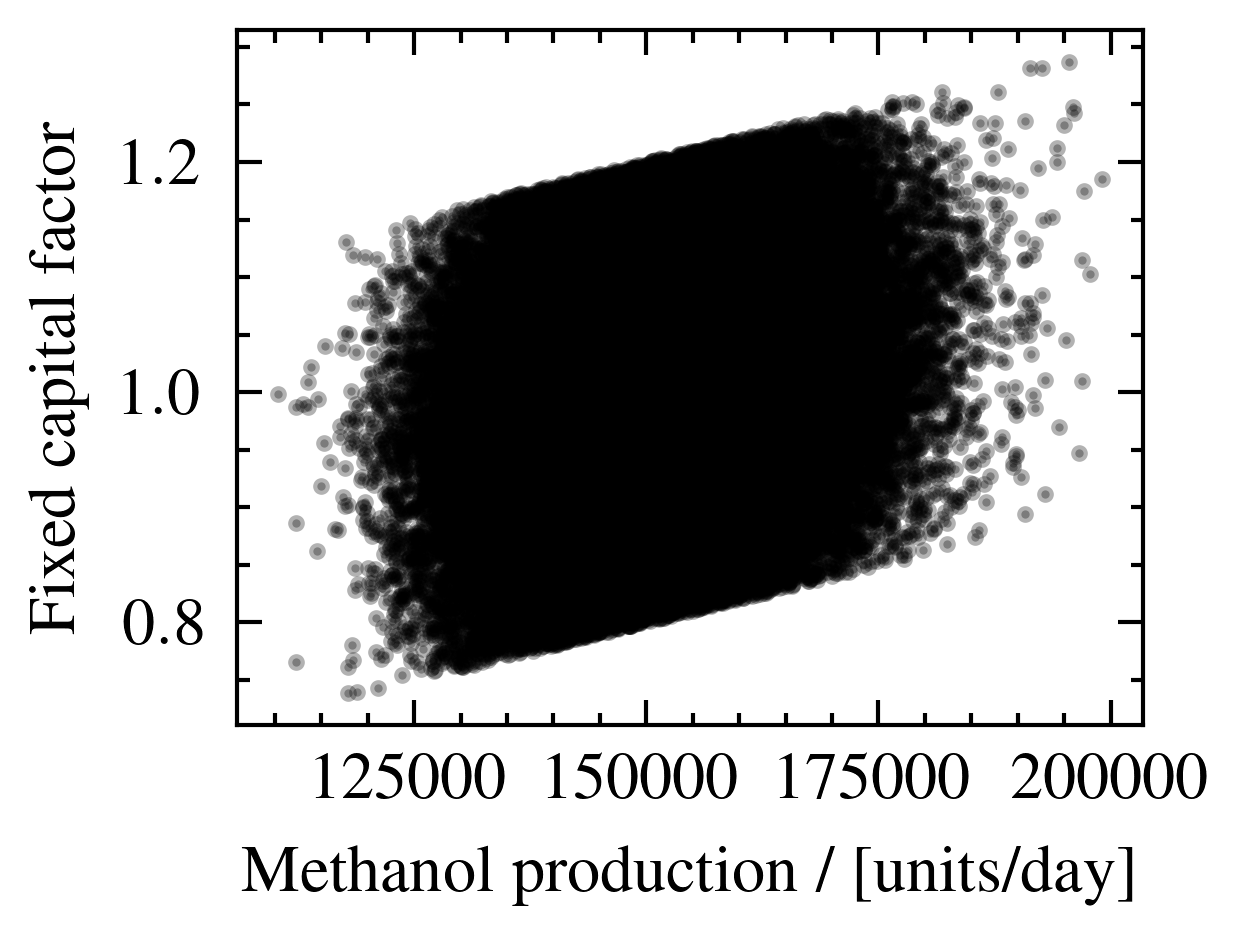

In [21]:
fig, ax = plt.subplots(figsize=(2.2, 1.7))

ax.scatter(mc_dependency["inputs"]["Methanol production"],
           mc_dependency["inputs"]["Fixed capital factor"],
           s=1, alpha=0.3)
ax.set_xlabel("Methanol production / [units/day]")
ax.set_ylabel("Fixed capital factor")

fig.tight_layout()
plt.show()

---

**Dependencies in the Deterministic Analyses**

This is the promise made back in the sensitivity and tornado sections, now delivered. A dependency is a property of the *plant*, not of the Monte Carlo run, so `sensitivity_data()` and `tornado_data()` resolve the very same DAG -- minus the noise, which belongs to Monte Carlo alone. Nothing needs re-configuring and no new argument is involved: `demo_plant` already carries the dependencies set up above, and both deterministic analyses pick them up as they are.

| | What the dependencies do | Why |
| --- | --- | --- |
| **Perturbations propagate** | Varying a parameter that drives others moves them with it, and anything downstream of *those*, before the economics are recomputed. | This is the fix for the caveat above: a bar or curve should show what actually happens when that parameter moves, and what actually happens includes the cascade. |
| **Dependents are never factors** | A parameter set by a dependency is left out of the tornado's factor list, and naming it in `sensitivity_data()` raises a `ValueError`. | It has no value of its own to hold everything else constant against. Vary one of its parents instead; the change reaches it. |

What dependencies do *not* do is change which kinds of parameter get ranked -- that stays `include_process_params`, exactly as before -- so configuring a dependency never silently adds bars to a tornado.

To see the difference, it helps to have the *same plant analyzed as if its parameters were independent* to compare against. Let's build that twin by stripping the dependency blocks back out, leaving every parameter at the baseline value it already had:

In [22]:
independent_plant = deepcopy(demo_plant)
independent_plant.update_configuration({"plant_name": "Demo Plant (no dependencies)"})

# Remove every dependency block. `update_configuration` *merges* nested dicts, so
# it can add a dependency but never take one away -- we pop the keys directly.
for props in independent_plant.variable_opex_inputs.values():
    props.pop("consumption_dependency", None)

for props in independent_plant.plant_products.values():
    props.pop("production_dependency", None)

independent_plant.project_uncertainties["fixed_capital_factor"].pop("dependency", None)

{'depends_on': {'production:methanol': 2e-06}, 'offset': 0.7}

Now the same tornado call on each -- identical arguments, identical baseline plant, differing only in whether the dependencies are declared:

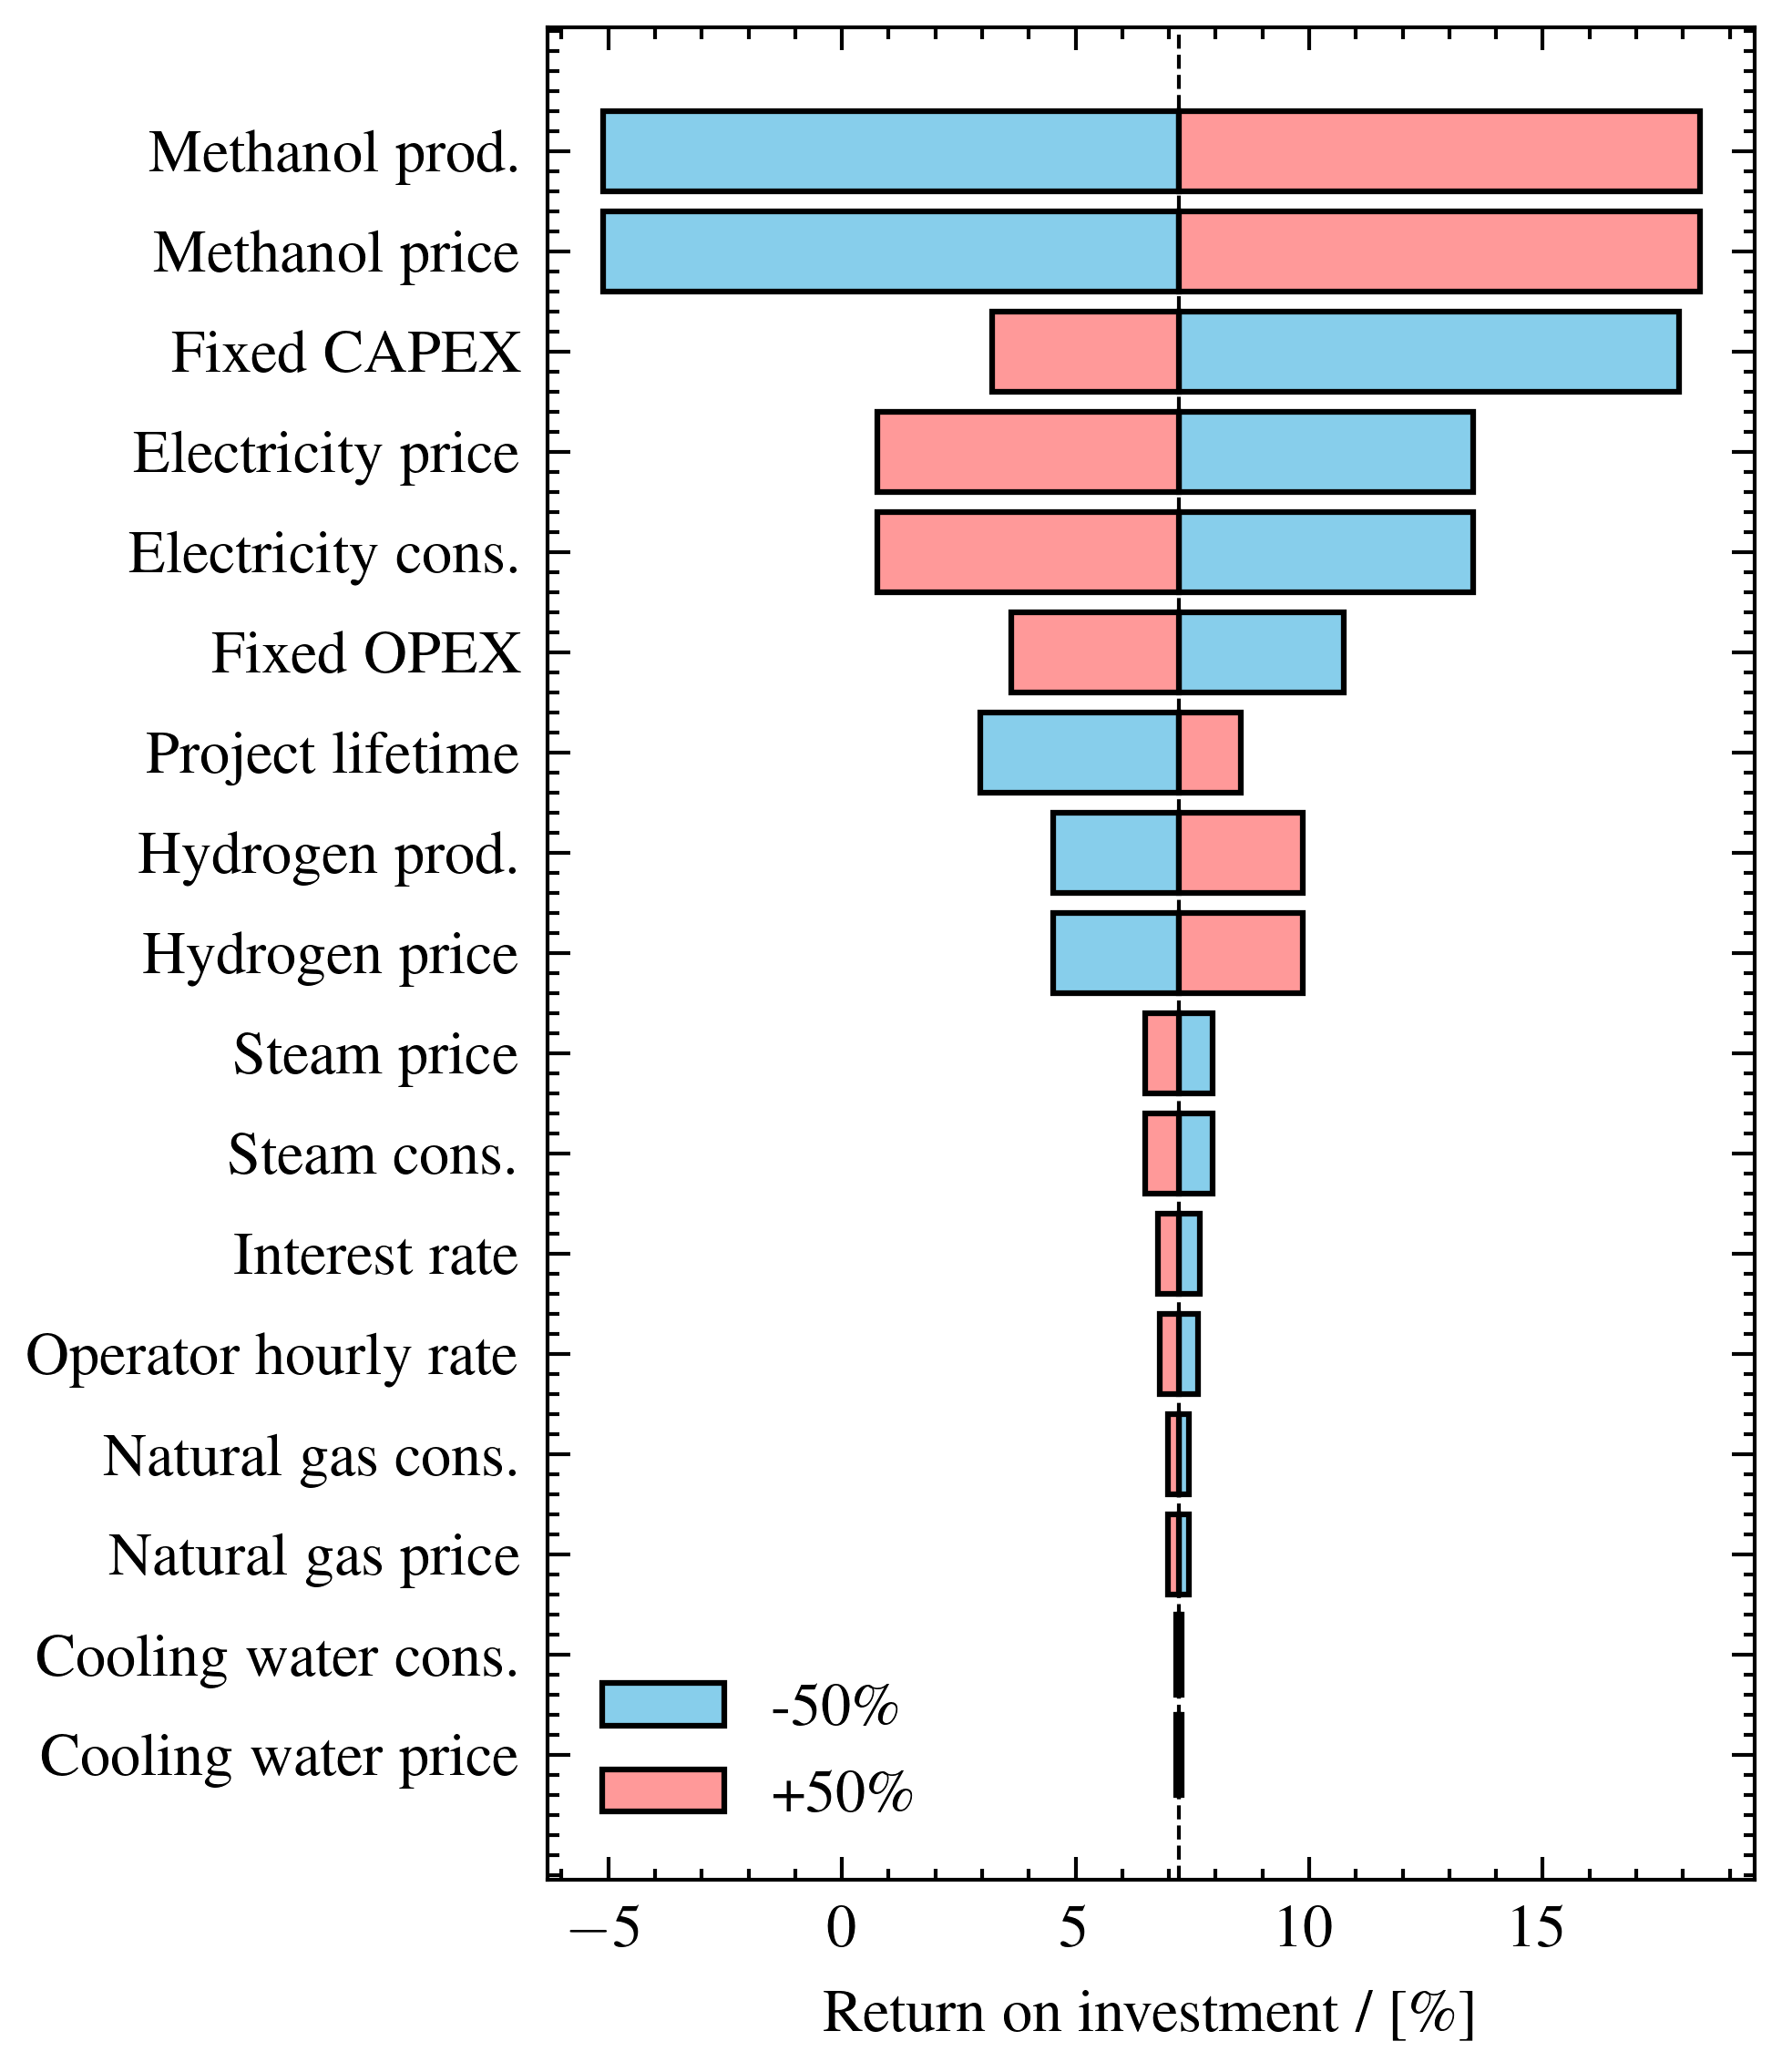

In [23]:
fig, ax = plot_tornado(tornado_data(plant=independent_plant, plus_minus_value=0.5,
                                    metric="ROI", include_process_params=True))

C:\Users\pbtamarona\OneDrive - Delft University of Technology\Documents\github-pbtamarona\OpenPyTEA\src\openpytea\plant.py:1238: UserWarning: Depreciation life exceeds the usable horizon (project lifetime minus service start year), so part of the depreciable basis is not written off within the project. This is legitimate for a statutory life longer than the project, but shorten the depreciation life or extend the project lifetime if a full write-off is intended.
  build_depreciation_array(


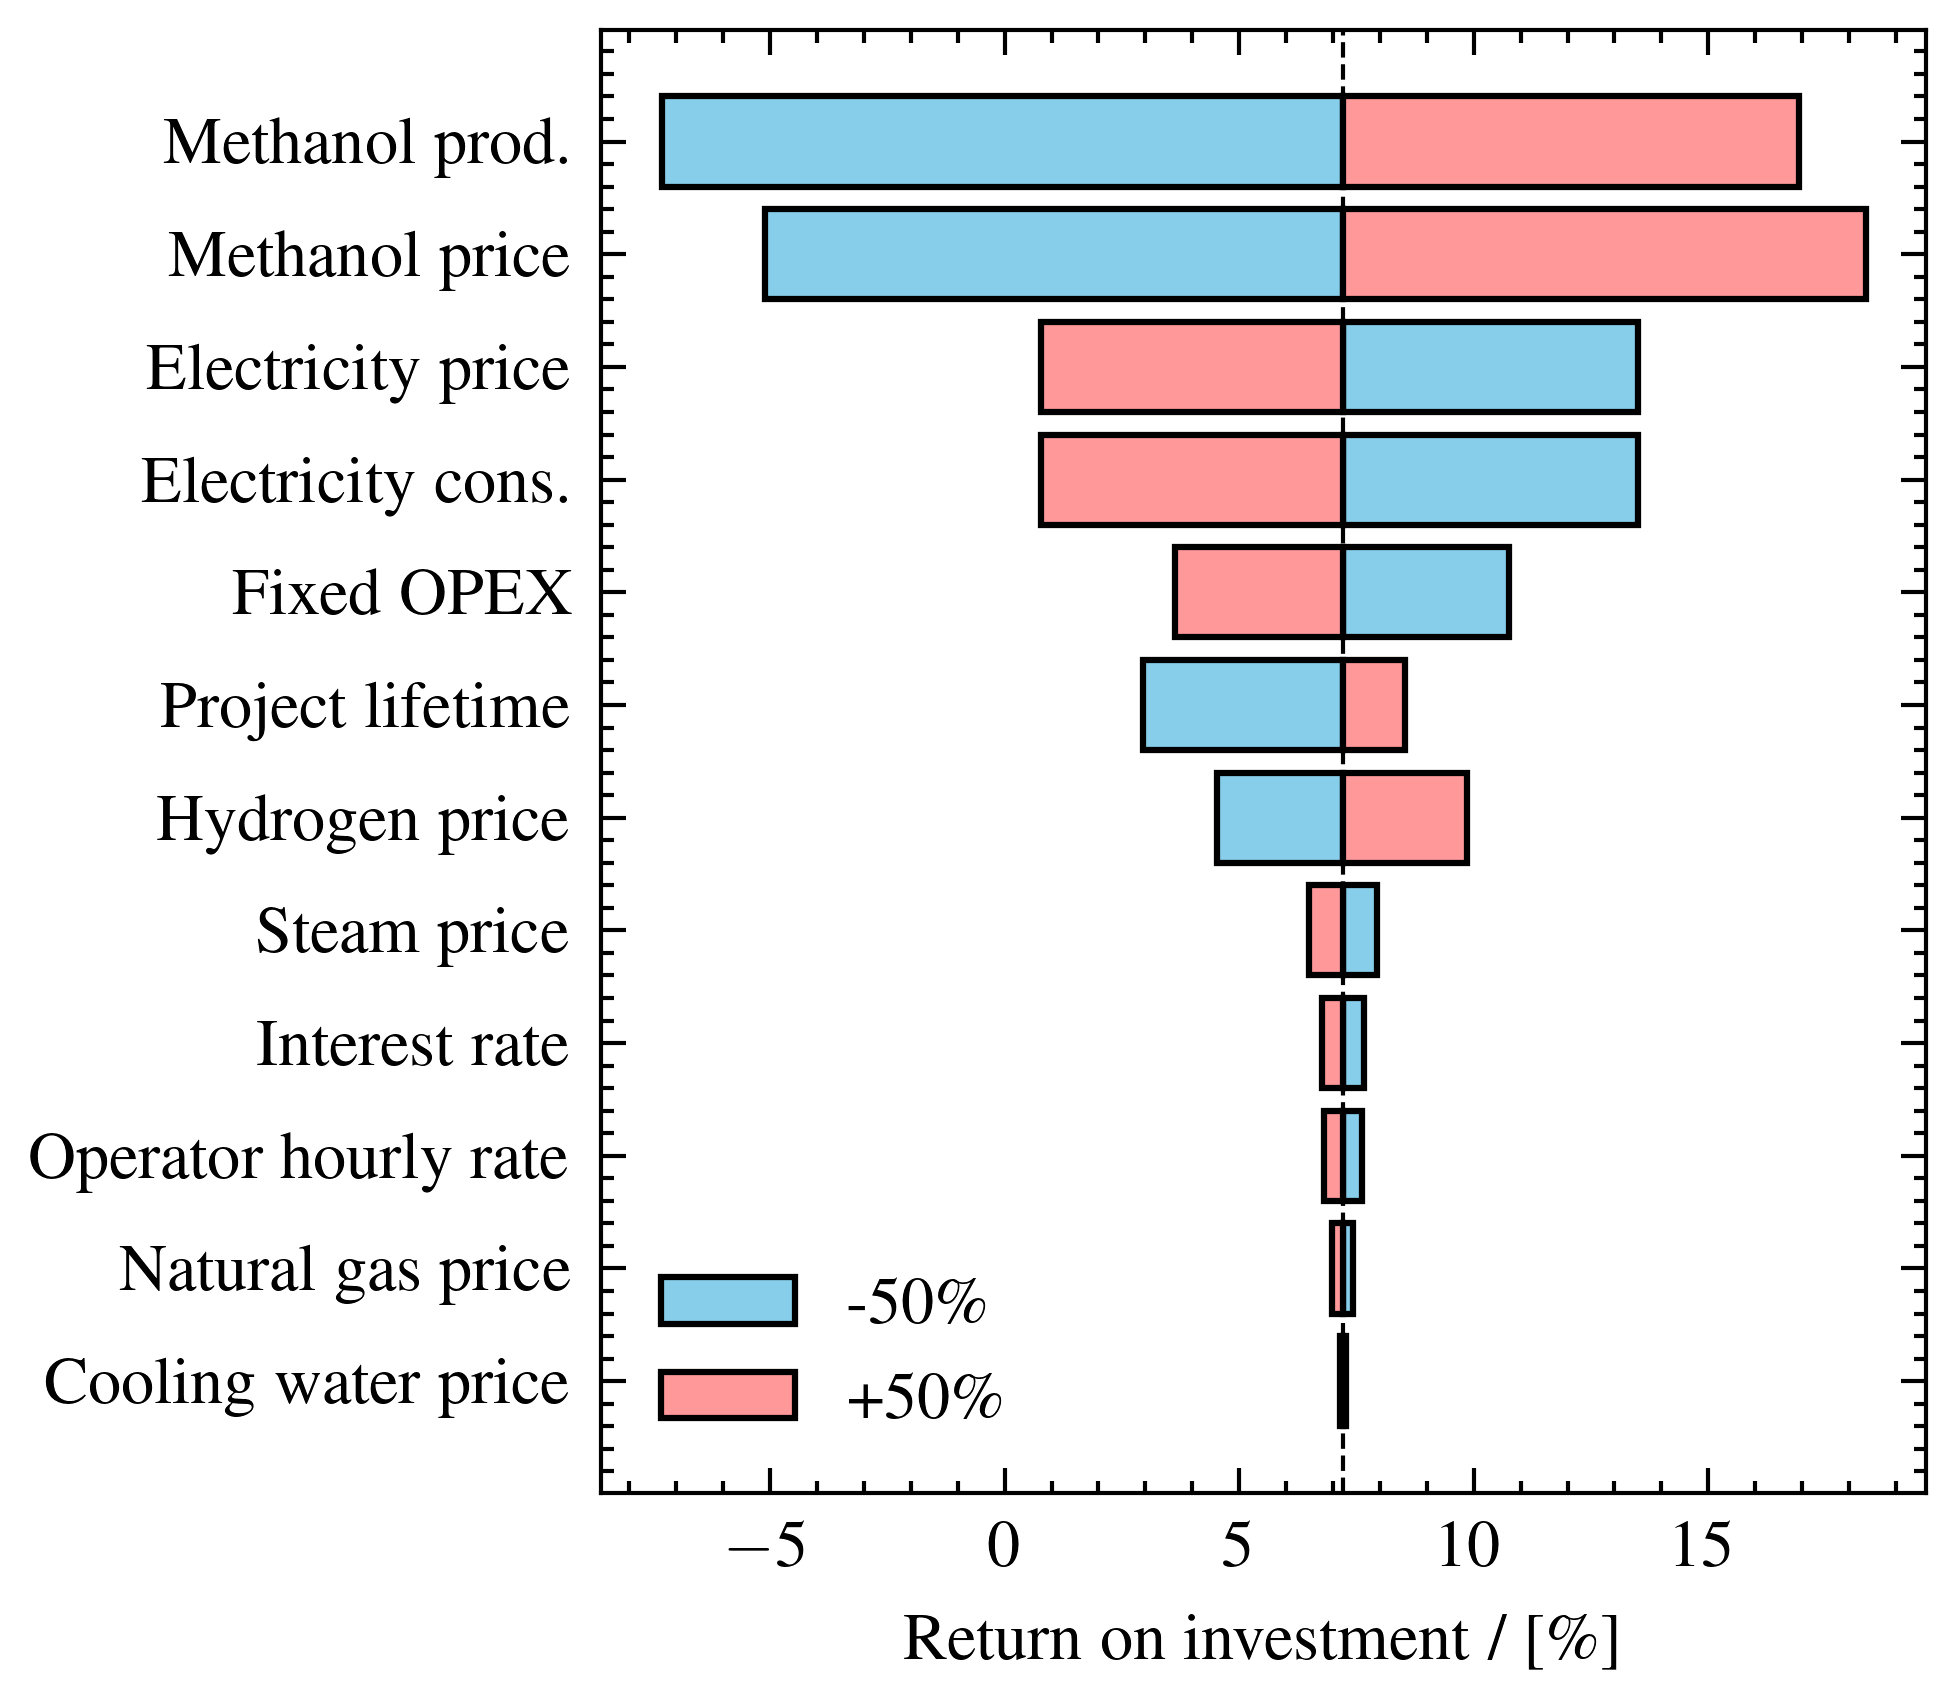

In [24]:
fig, ax = plot_tornado(tornado_data(plant=demo_plant, plus_minus_value=0.5,
                                    metric="ROI", include_process_params=True))

The dependent chart is the shorter one: 12 factors against 17. Five have dropped out, and each for the same reason -- it no longer has a value of its own to vary.

* `Cooling water cons.`, `Steam cons.`, `Natural gas cons.` and `Hydrogen prod.` are all set by the DAG.
* `Fixed CAPEX` too: `fixed_capital_factor` was tied to methanol production, so a bar claiming it could move on its own would be a fiction.

What remains are the genuinely independent knobs -- the prices, the financial assumptions, `Electricity cons.` (the one utility we never tied to anything), and `Methanol prod.`, the single root of the whole graph.

`Methanol prod.`'s bar has also changed shape. It now spans an ROI of -7.3 % to 17.3 % rather than -5.1 % to 18.4 %, because it is no longer moving alone: hydrogen's byproduct production, three utility consumptions and `fixed_capital_factor` all move with it. The bar got **wider**, not narrower -- more on why below.

The one-way sweep tells the same story with more resolution. `sensitivity_data()` accepts a list of plants, so both can be swept in a single call and drawn on one figure -- and note that it needs no `include_process_params`, since it takes an explicit parameter rather than enumerating a list:

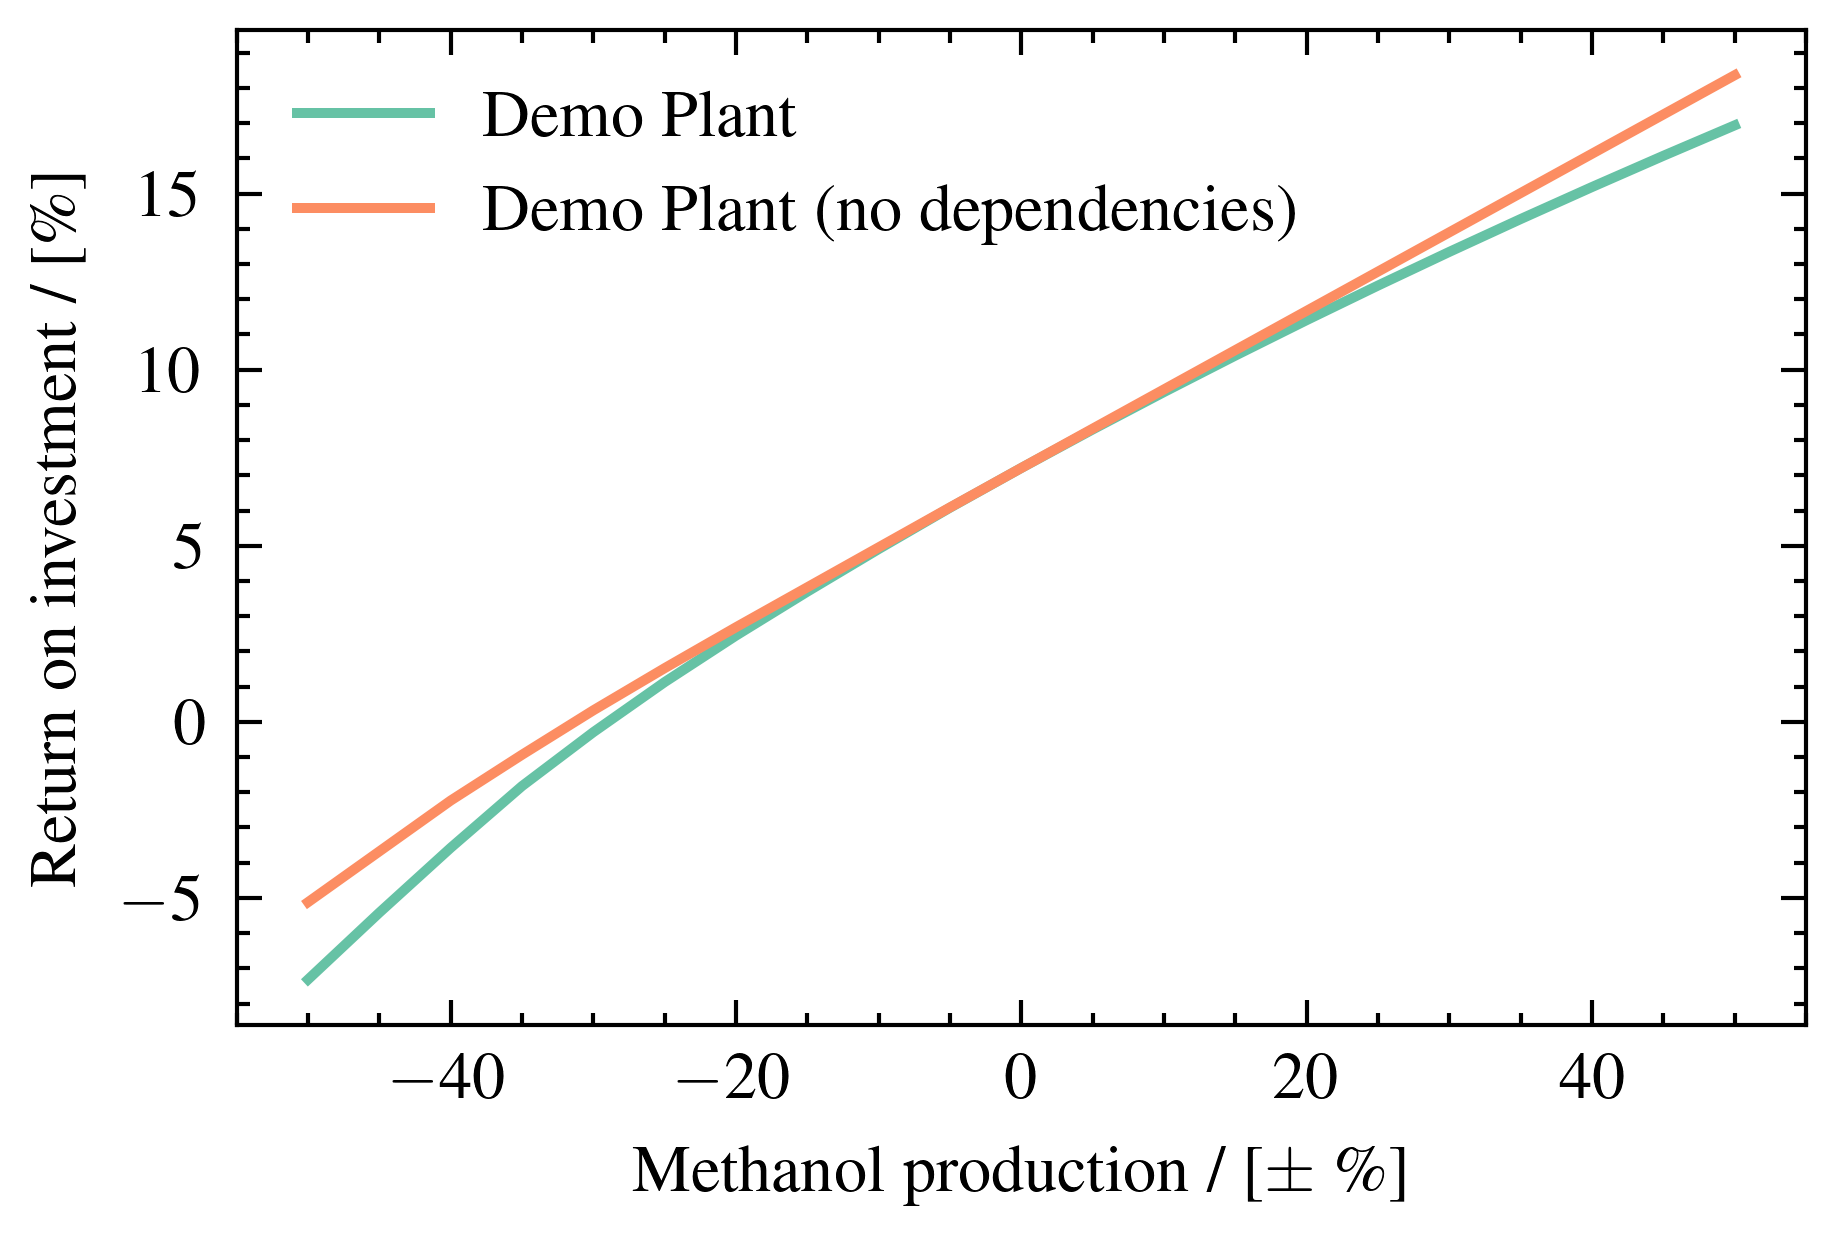

In [25]:
roi_comparison = sensitivity_data(
    plants=[demo_plant, independent_plant],
    parameter="methanol.production",
    metric="ROI",
    plus_minus_value=0.5,
)

fig, ax = plot_sensitivity(roi_comparison)

The two curves meet at 0 % -- the dependencies above were deliberately given weights and offsets that reproduce each parameter's configured baseline, so this is the same plant at the centre of the sweep -- and separate either side of it.

The dependent curve is **steeper in both directions**: at -50 % methanol production it reaches an ROI of about -7.3 % against the independent curve's -5.1 %, and at +50 % it reaches 17.3 % against 18.4 %. Hydrogen is the main reason. Its production is tied to methanol's, so a shortfall in the main product takes the byproduct revenue down with it, instead of leaving it politely fixed at 50,000 units/day the way an independent sweep assumes. Rising utility consumption and the production-linked `fixed_capital_factor` pull in the same direction at the top end.

The practical reading: treating these parameters as independent **understates this plant's exposure to a production shortfall** and overstates the gain from a scale-up. That gap is exactly what the dependency graph exists to capture -- and it is the same graph, with the same numbers, that shaped the Monte Carlo distributions earlier in this section.

**Varying a dependent is refused.** Cooling water's consumption is set by methanol production, so there is no scenario in which it moves while everything else stays put -- asking for one raises a `ValueError` that names the parents to vary instead:

In [26]:
try:
    sensitivity_data(plants=demo_plant, parameter="cooling_water.consumption", plus_minus_value=0.5)
except ValueError as e:
    print(f"ValueError: {e}")

ValueError: Cannot vary 'variable_opex_inputs.cooling_water.consumption' on plant 'Demo Plant': it is set by a dependency on plant_products.methanol.production, so it has no value of its own to vary. Vary one of those instead -- the change propagates through to 'variable_opex_inputs.cooling_water.consumption'.


---

◀ **Previous:** [Part 3: Cost Analysis and Sensitivity](part_3_analysis.ipynb) &nbsp;|&nbsp; **Next:** [Part 5: TEA Using Configuration Files](part_5_configuration_files.ipynb) ▶